<center><font size=6> Bank Churn Prediction </font></center>

## Problem Statement

### Context

Businesses like banks which provide service have to worry about problem of 'Customer Churn' i.e. customers leaving and joining another service provider. It is important to understand which aspects of the service influence a customer's decision in this regard. Management can concentrate efforts on improvement of service, keeping in mind these priorities.

### Objective

You as a Data scientist with the  bank need to  build a neural network based classifier that can determine whether a customer will leave the bank  or not in the next 6 months.

### Data Dictionary

* CustomerId: Unique ID which is assigned to each customer

* Surname: Last name of the customer

* CreditScore: It defines the credit history of the customer.
  
* Geography: A customer’s location
   
* Gender: It defines the Gender of the customer
   
* Age: Age of the customer
    
* Tenure: Number of years for which the customer has been with the bank

* NumOfProducts: refers to the number of products that a customer has purchased through the bank.

* Balance: Account balance

* HasCrCard: It is a categorical variable which decides whether the customer has credit card or not.

* EstimatedSalary: Estimated salary

* isActiveMember: Is is a categorical variable which decides whether the customer is active member of the bank or not ( Active member in the sense, using bank products regularly, making transactions etc )

* Exited : whether or not the customer left the bank within six month. It can take two values
** 0=No ( Customer did not leave the bank )
** 1=Yes ( Customer left the bank )

In [323]:
# Installing the libraries with the specified version.
!pip3 install tensorflow==2.15.0 scikit-learn==1.2.2 seaborn==0.13.1 matplotlib==3.7.1 numpy==1.25.2 pandas==2.0.3 imbalanced-learn==0.10.1 -q --user

## Importing necessary libraries

In [324]:
# Libraries to help with reading and manipulating data
import pandas as pd
import numpy as np

# libaries to help with data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Library to split data
from sklearn.model_selection import train_test_split

# library to import to standardize the data
from sklearn.preprocessing import StandardScaler, LabelEncoder

# importing different functions to build models
import tensorflow as tf
from tensorflow import keras
from keras import backend
from keras.models import Sequential
from keras.layers import Dense, Dropout

# importing SMOTE
from imblearn.over_sampling import SMOTE

# importing metrics
from sklearn.metrics import confusion_matrix,roc_curve,classification_report,recall_score

import random
import time

# imports for ROC
from sklearn.metrics import roc_curve, auc, precision_recall_curve
from sklearn.metrics import confusion_matrix

# Library to avoid the warnings
import warnings
warnings.filterwarnings("ignore")

## Loading the dataset

In [325]:
#mount the google drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [326]:
df = pd.read_csv('/content/drive/My Drive/bank.csv')
# making a copy of the data
data = df.copy()

## Data Overview

In [327]:
print(f'Data contains {data.shape[0]} rows and {data.shape[1]} columns')

Data contains 10000 rows and 14 columns


In [328]:
data.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [329]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [330]:
print(f'The null values in the data are: \n{data.isnull().sum()}')

The null values in the data are: 
RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64


In [331]:
print(f'The unique values in the data are: \n{data.nunique()}')

The unique values in the data are: 
RowNumber          10000
CustomerId         10000
Surname             2932
CreditScore          460
Geography              3
Gender                 2
Age                   70
Tenure                11
Balance             6382
NumOfProducts          4
HasCrCard              2
IsActiveMember         2
EstimatedSalary     9999
Exited                 2
dtype: int64


## Exploratory Data Analysis

In [332]:
#From the Data overview we can infer that RowNumber and CustomerId are unique for each row and hence can be dropped.
print(f'Number of unique values in column RowNumber: {data["RowNumber"].nunique()}, \nNumber of unique values in column CustomerId: {data["CustomerId"].nunique()}')
data.drop(columns=['RowNumber', 'CustomerId'], inplace=True)

Number of unique values in column RowNumber: 10000, 
Number of unique values in column CustomerId: 10000


In [333]:
#surname is not a relevant feature for the model, exploring the unique values in the column
print(f'Number of unique values in column Surname: {data["Surname"].nunique()}')
print(data['Surname'].value_counts())
#having 2932 unique values in the column Surname, it is not a relevant feature for the model and hence can be dropped.
data.drop(columns=['Surname'], inplace=True)

Number of unique values in column Surname: 2932
Surname
Smith        32
Martin       29
Scott        29
Walker       28
Brown        26
             ..
Wells         1
Calzada       1
Gresswell     1
Aguirre       1
Morales       1
Name: count, Length: 2932, dtype: int64


In [334]:
print(f'Statistical description of the data: \n{data.describe().T}')

Statistical description of the data: 
                   count           mean           std     min       25%  \
CreditScore      10000.0     650.528800     96.653299  350.00    584.00   
Age              10000.0      38.921800     10.487806   18.00     32.00   
Tenure           10000.0       5.012800      2.892174    0.00      3.00   
Balance          10000.0   76485.889288  62397.405202    0.00      0.00   
NumOfProducts    10000.0       1.530200      0.581654    1.00      1.00   
HasCrCard        10000.0       0.705500      0.455840    0.00      0.00   
IsActiveMember   10000.0       0.515100      0.499797    0.00      0.00   
EstimatedSalary  10000.0  100090.239881  57510.492818   11.58  51002.11   
Exited           10000.0       0.203700      0.402769    0.00      0.00   

                        50%          75%        max  
CreditScore         652.000     718.0000     850.00  
Age                  37.000      44.0000      92.00  
Tenure                5.000       7.0000      10.

### Univariate Analysis

# Reusable Functions

In [335]:
# boxplot and a histogram.


def histogram_boxplot(data, feature, figsize=(12, 7), kde=False, bins=None):
    """
    Boxplot and histogram combined

    data: dataframe
    feature: dataframe column
    figsize: size of figure (default (12,7))
    kde: density curve (default False)
    bins: number of bins for histogram (default None)
    """
    f2, (ax_box2, ax_hist2) = plt.subplots(
        nrows=2,  # Number of rows of the subplot grid= 2
        sharex=True,  # x-axis will be shared among all subplots
        gridspec_kw={"height_ratios": (0.25, 0.75)},
        figsize=figsize,
    )  # creating the 2 subplots
    sns.boxplot(
        data=data, x=feature, ax=ax_box2, showmeans=True, color="violet"
    )  # boxplot will be created and a star will indicate the mean value of the column
    sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2, bins=bins, palette="winter"
    ) if bins else sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2
    )  # For histogram
    ax_hist2.axvline(
        data[feature].mean(), color="green", linestyle="--"
    )  # Add mean to the histogram
    ax_hist2.axvline(
        data[feature].median(), color="black", linestyle="-"
    )  # Add median to the histogram

In [336]:
# labeled barplots function


def labeled_barplot(data, feature, perc=False, n=None):
    """
    Barplot with percentage at the top

    data: dataframe
    feature: dataframe column
    perc: whether to display percentages instead of count (default is False)
    n: displays the top n category levels (default is None, i.e., display all levels)
    """

    total = len(data[feature])  # length of the column
    count = data[feature].nunique()
    if n is None:
        plt.figure(figsize=(count + 1, 5))
    else:
        plt.figure(figsize=(n + 1, 5))

    plt.xticks(rotation=90, fontsize=15)
    ax = sns.countplot(
        data=data,
        x=feature,
        palette="Paired",
        order=data[feature].value_counts().index[:n].sort_values(),
    )

    for p in ax.patches:
        if perc == True:
            label = "{:.1f}%".format(
                100 * p.get_height() / total
            )  # percentage of each class of the category
        else:
            label = p.get_height()  # count of each level of the category

        x = p.get_x() + p.get_width() / 2  # width of the plot
        y = p.get_height()  # height of the plot

        ax.annotate(
            label,
            (x, y),
            ha="center",
            va="center",
            size=12,
            xytext=(0, 5),
            textcoords="offset points",
        )  # annotate the percentage

    plt.show()  # show the plot

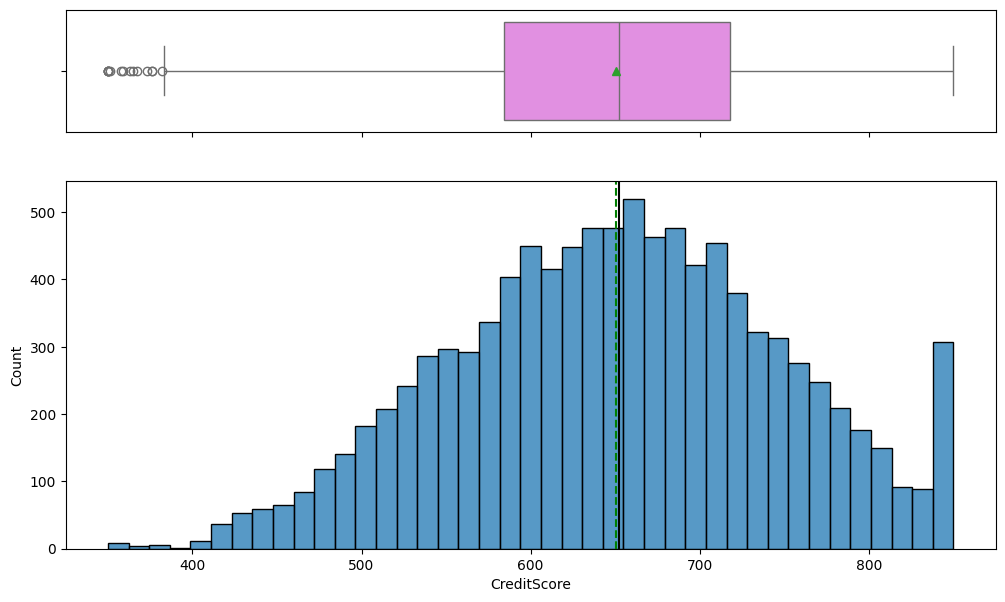

In [337]:
#CreditScore distribution
histogram_boxplot(data, 'CreditScore')

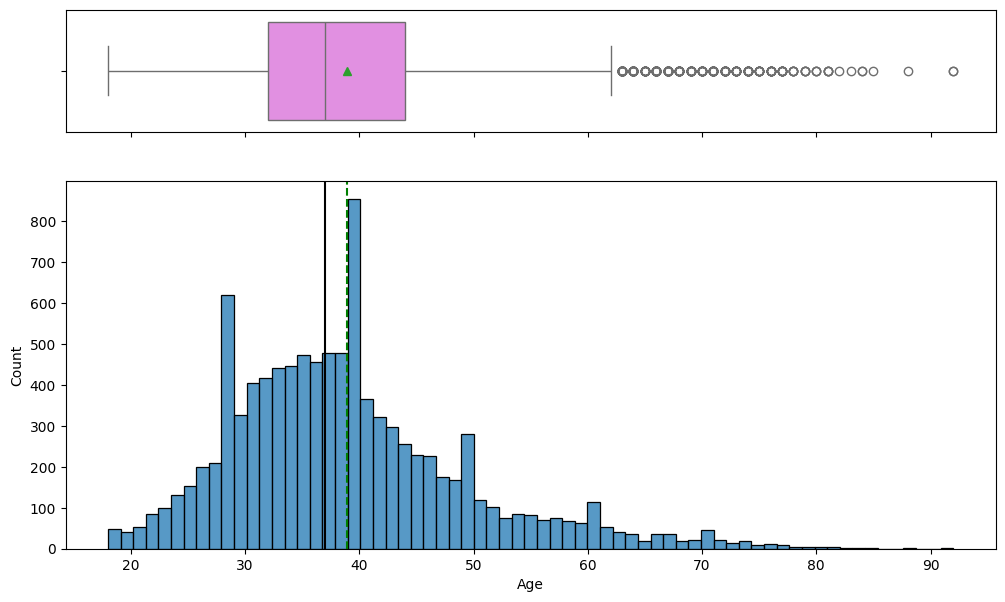

In [338]:
#Age distribution
histogram_boxplot(data, 'Age')

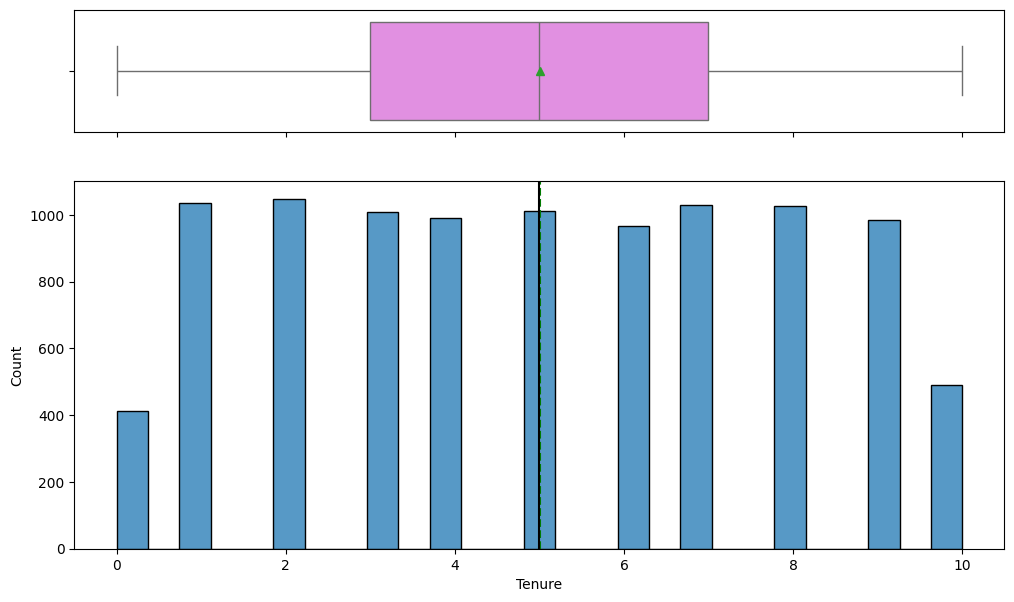

In [339]:
#Tenure distribution
histogram_boxplot(data, 'Tenure')

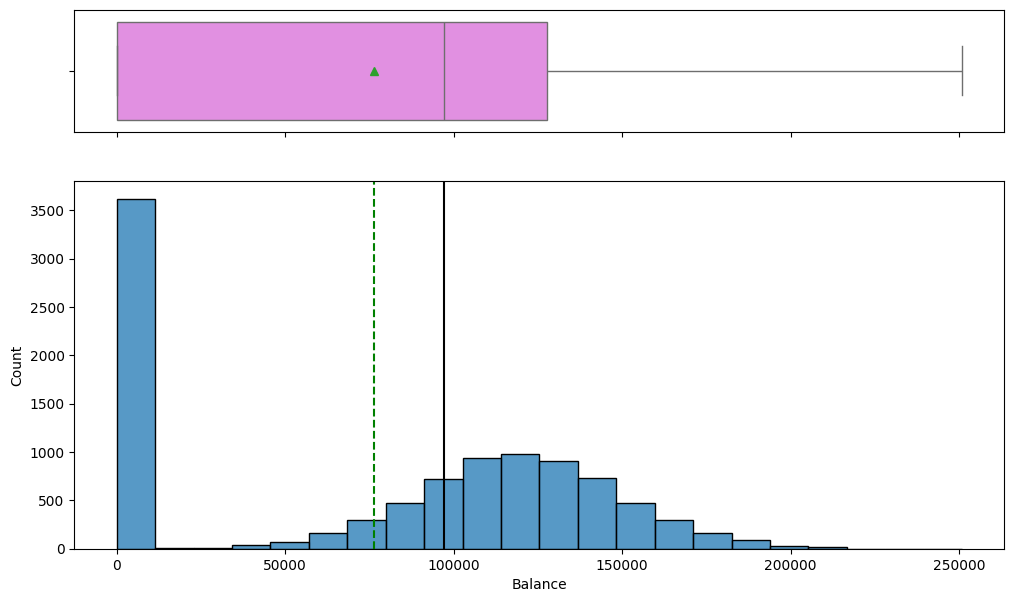

In [340]:
#Balance distribution
histogram_boxplot(data, 'Balance')

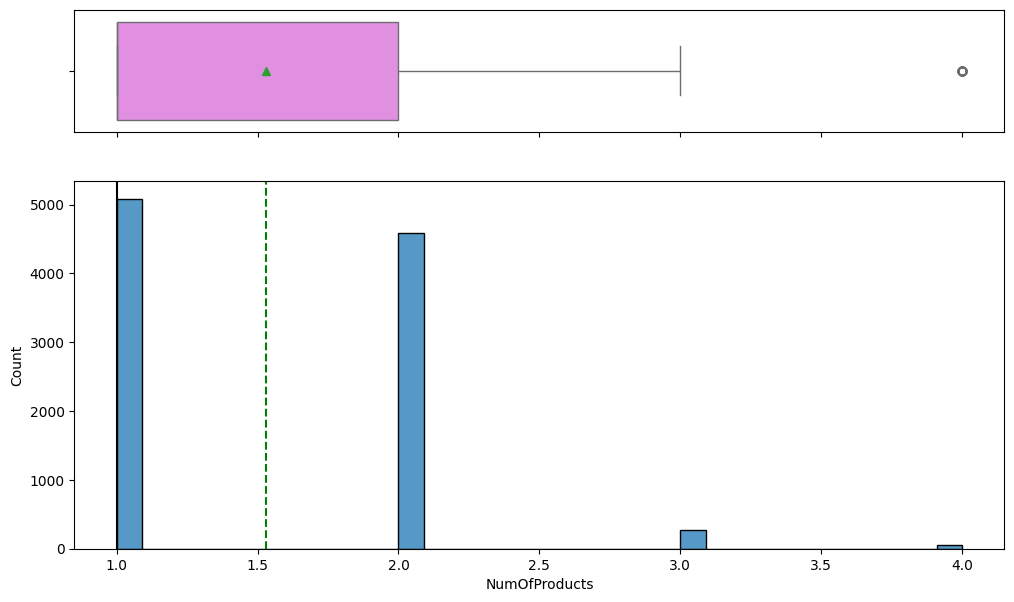

In [341]:
#NumOfProducts distribution
histogram_boxplot(data, 'NumOfProducts')

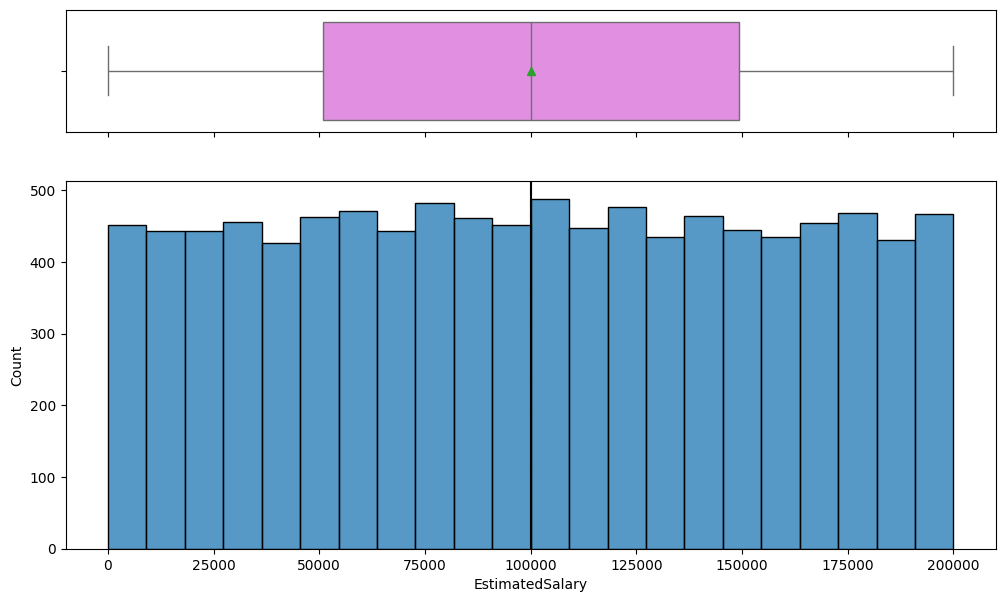

In [342]:
#EstimatedSalary distribution
histogram_boxplot(data, 'EstimatedSalary')

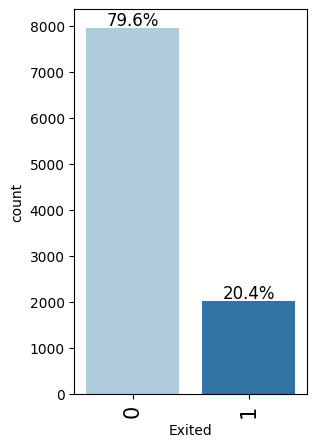

In [343]:
#Exited distribution
labeled_barplot(data, 'Exited', perc=True)

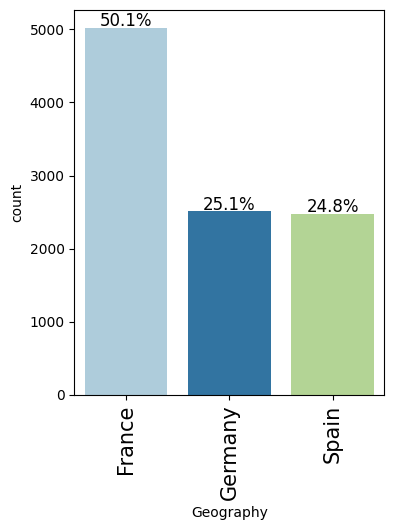

In [344]:
#geography distribution
labeled_barplot(data, 'Geography', perc=True)

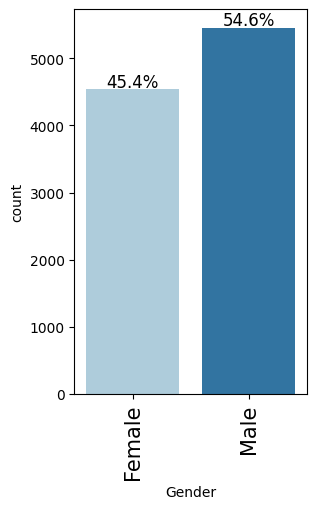

In [345]:
#gender distribution
labeled_barplot(data, 'Gender', perc=True)

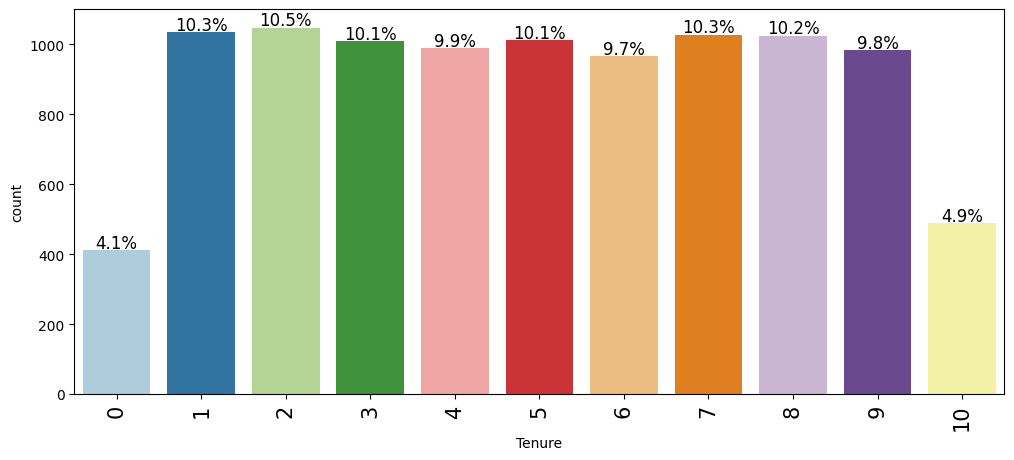

In [346]:
#tenure distribution
labeled_barplot(data, 'Tenure', perc=True)

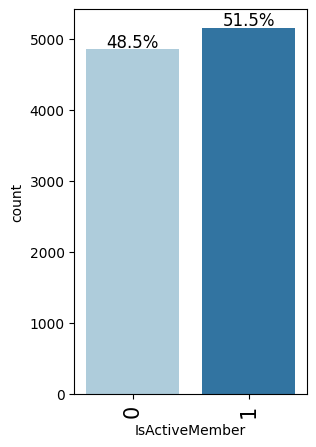

In [347]:
#active member distribution
labeled_barplot(data, 'IsActiveMember', perc=True)

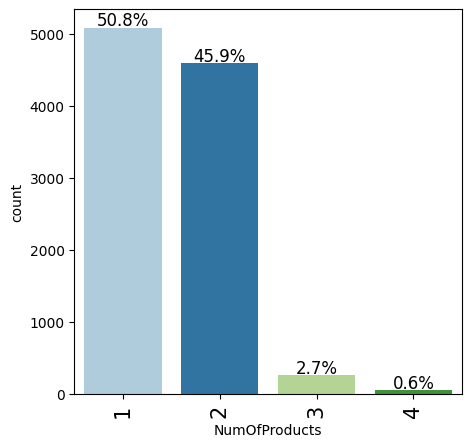

In [348]:
#number of products distribution
labeled_barplot(data, 'NumOfProducts', perc=True)

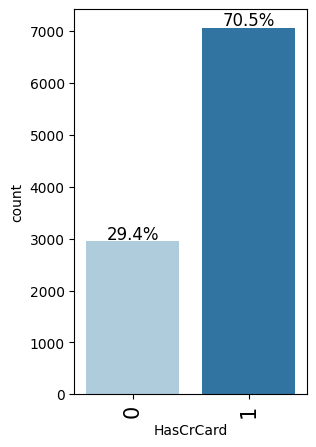

In [349]:
#has credit card distribution
labeled_barplot(data, 'HasCrCard', perc=True)

### Bivariate Analysis

# Reusable function

In [350]:
# plot stacked bar chart


def stacked_barplot(data, predictor, target):
    """
    Print the category counts and plot a stacked bar chart

    data: dataframe
    predictor: independent variable
    target: target variable
    """
    count = data[predictor].nunique()
    sorter = data[target].value_counts().index[-1]
    tab1 = pd.crosstab(data[predictor], data[target], margins=True).sort_values(
        by=sorter, ascending=False
    )
    print(tab1)
    print("-" * 120)
    tab = pd.crosstab(data[predictor], data[target], normalize="index").sort_values(
        by=sorter, ascending=False
    )
    tab.plot(kind="bar", stacked=True, figsize=(count + 1, 5))
    plt.legend(
        loc="lower left",
        frameon=False,
    )
    plt.legend(loc="upper left", bbox_to_anchor=(1, 1))
    plt.show()

In [351]:
# defining the list of numerical columns
cols_list = ["CreditScore","Age","Tenure","Balance","EstimatedSalary"]

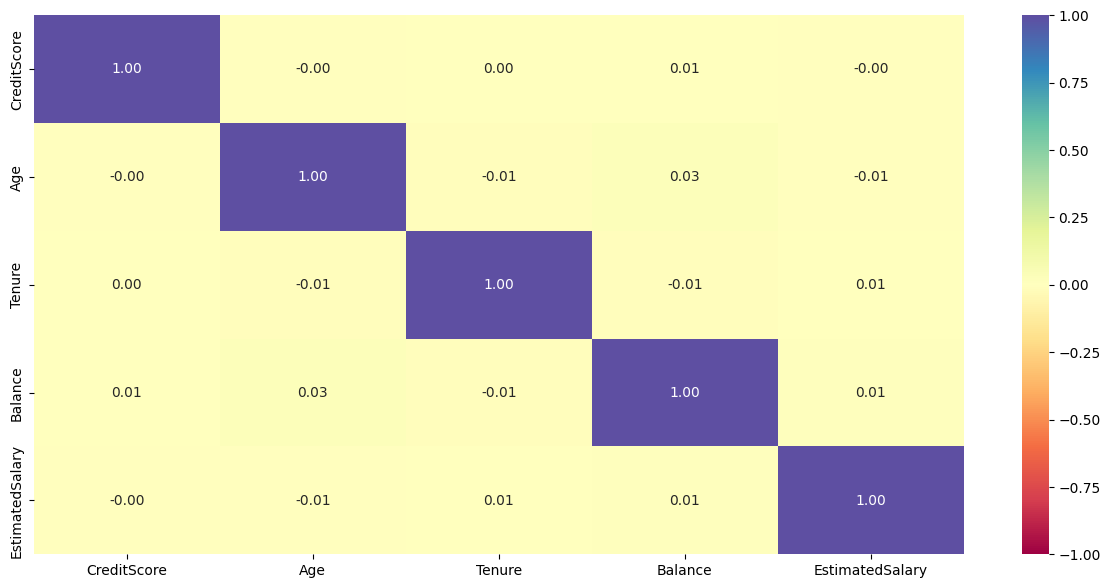

In [352]:
plt.figure(figsize=(15, 7))
sns.heatmap(data[cols_list].corr(), annot=True, vmin=-1, vmax=1, fmt=".2f", cmap="Spectral")
plt.show()

Exited             0     1    All
IsActiveMember                   
All             7963  2037  10000
0               3547  1302   4849
1               4416   735   5151
------------------------------------------------------------------------------------------------------------------------


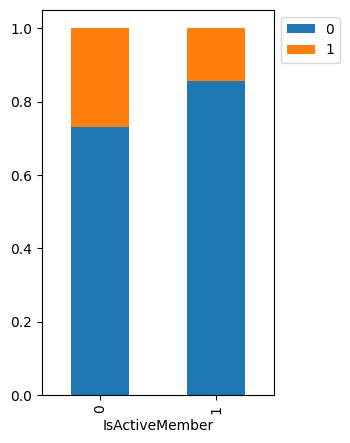

In [353]:
# Exited Vs Is active member
stacked_barplot(data, "IsActiveMember", "Exited")


Exited            0     1    All
NumOfProducts                   
All            7963  2037  10000
1              3675  1409   5084
2              4242   348   4590
3                46   220    266
4                 0    60     60
------------------------------------------------------------------------------------------------------------------------


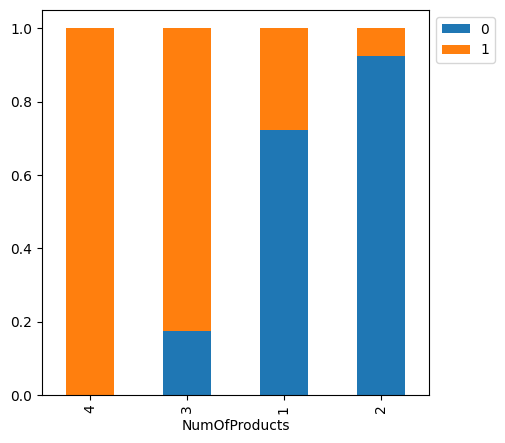

In [354]:
# Exited Vs Number of products
stacked_barplot(data, "NumOfProducts", "Exited")

Exited        0     1    All
HasCrCard                   
All        7963  2037  10000
1          5631  1424   7055
0          2332   613   2945
------------------------------------------------------------------------------------------------------------------------


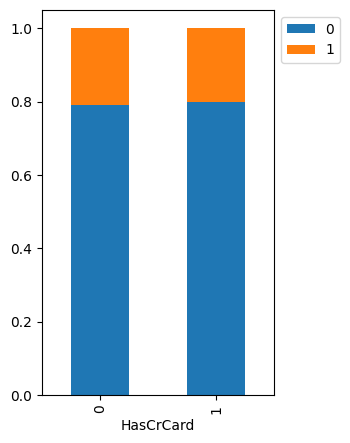

In [355]:
# Exited Vs Has credit card
stacked_barplot(data, "HasCrCard", "Exited")

Exited        0     1    All
Geography                   
All        7963  2037  10000
Germany    1695   814   2509
France     4204   810   5014
Spain      2064   413   2477
------------------------------------------------------------------------------------------------------------------------


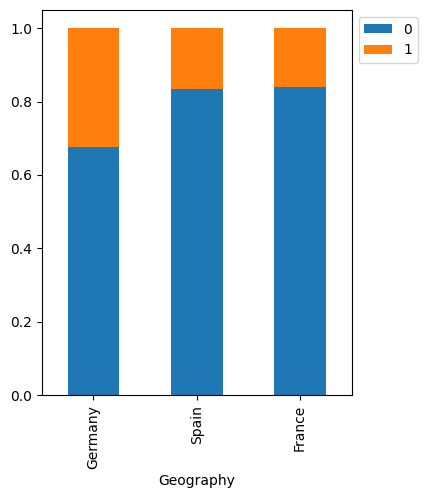

In [356]:
# Exited Vs Geography
stacked_barplot(data, "Geography", "Exited")

Exited     0     1    All
Gender                   
All     7963  2037  10000
Female  3404  1139   4543
Male    4559   898   5457
------------------------------------------------------------------------------------------------------------------------


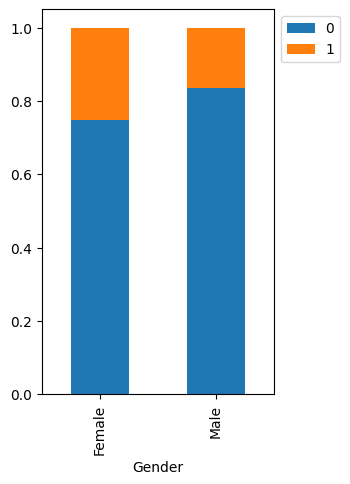

In [357]:
# Exited Vs Gender
stacked_barplot(data, "Gender", "Exited")

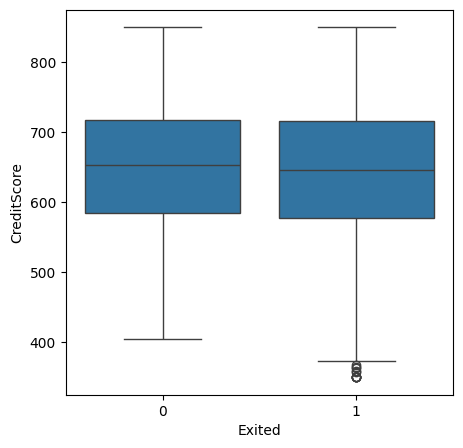

In [358]:
# Exited Vs Credit Score
plt.figure(figsize=(5,5))
sns.boxplot(y='CreditScore',x='Exited',data=data)
plt.show()

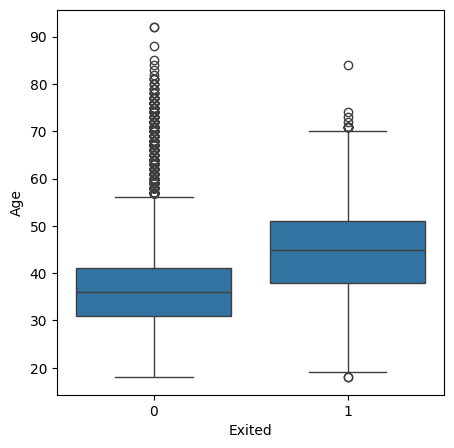

In [359]:
# Exited Vs Age
plt.figure(figsize=(5,5))
sns.boxplot(y='Age',x='Exited',data=data)
plt.show()

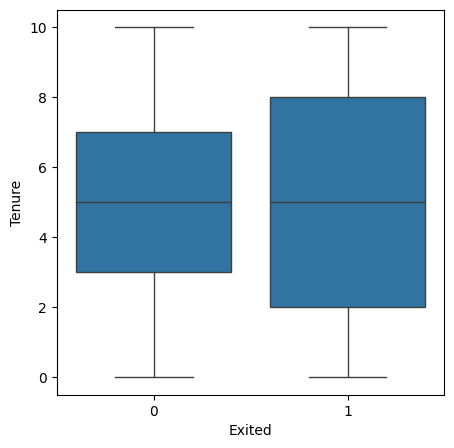

In [360]:
# Exited Vs Tenure
plt.figure(figsize=(5,5))
sns.boxplot(y='Tenure',x='Exited',data=data)
plt.show()

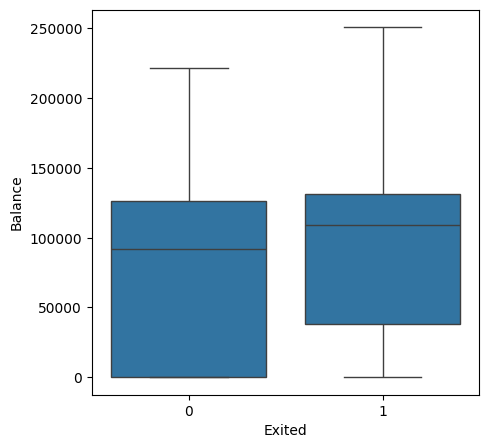

In [361]:
# Exited Vs Balance
plt.figure(figsize=(5,5))
sns.boxplot(y='Balance',x='Exited',data=data)
plt.show()

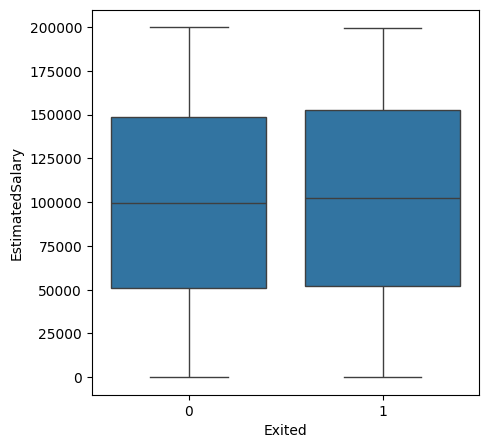

In [362]:
# Exited Vs Estimated Salary
plt.figure(figsize=(5,5))
sns.boxplot(y='EstimatedSalary',x='Exited',data=data)
plt.show()

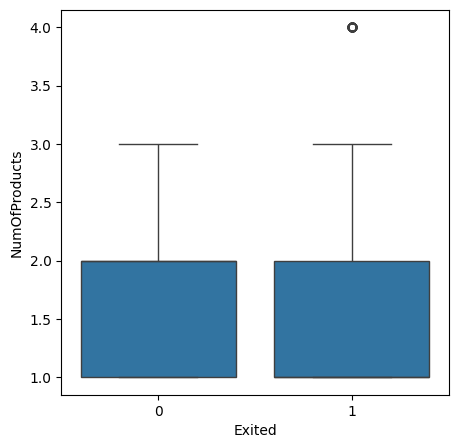

In [363]:
# Exited Vs Number of Products
plt.figure(figsize=(5,5))
sns.boxplot(y='NumOfProducts',x='Exited',data=data)
plt.show()


## Data Preprocessing

In [364]:
# checking if there are any negative values in the numerical columns
for i in cols_list:
    print(f'Negative values in {i}: {data[data[i] < 0][i].count()}')

Negative values in CreditScore: 0
Negative values in Age: 0
Negative values in Tenure: 0
Negative values in Balance: 0
Negative values in EstimatedSalary: 0


### Dummy Variable Creation

In [365]:
data = pd.get_dummies(data,columns=data.select_dtypes(include=["object"]).columns.tolist(),drop_first=True)
data = data.astype(float)
data.head()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain,Gender_Male
0,619.0,42.0,2.0,0.00,1.0,1.0,1.0,101348.88,1.0,0.0,0.0,0.0
1,608.0,41.0,1.0,83807.86,1.0,0.0,1.0,112542.58,0.0,0.0,1.0,0.0
2,502.0,42.0,8.0,159660.80,3.0,1.0,0.0,113931.57,1.0,0.0,0.0,0.0
3,699.0,39.0,1.0,0.00,2.0,0.0,0.0,93826.63,0.0,0.0,0.0,0.0
4,850.0,43.0,2.0,125510.82,1.0,1.0,1.0,79084.10,0.0,0.0,1.0,0.0


### Train-validation-test Split

In [366]:
X = data.drop(['Exited'],axis=1) # Dropping the Exited column as it required to be predicted
y = data['Exited'] # Assigning the Exited column to y

In [367]:
# Splitting the dataset into the Training and Testing set.
X_initial_train, X_test, y_initial_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42,stratify=y,shuffle = True)

In [368]:
# Splitting the dataset into the Training and Validation set.
X_train, X_val, y_train, y_val = train_test_split(X_initial_train, y_initial_train, test_size = 0.1, random_state = 42,stratify=y_initial_train,shuffle = True)

In [369]:
print(f"Train size: {len(X_train)}, Validation size: {len(X_val)}, Test size: {len(X_test)}")

Train size: 7200, Validation size: 800, Test size: 2000


### Data Normalization

In [370]:
# standard scaler for scaling the data for efficient model building
sc = StandardScaler()

X_train[cols_list] = sc.fit_transform(X_train[cols_list])
X_val[cols_list] = sc.transform(X_val[cols_list])
X_test[cols_list] = sc.transform(X_test[cols_list])

## Model Building

### Model Evaluation Criterion

# Recall is the ideal metric in this case as we want to avoid the false negatives in customer churn process.

In [371]:
#Confusion matrix resuable function
def make_confusion_matrix(actual_targets, predicted_targets):
    """
    To plot the confusion_matrix with percentages

    actual_targets: actual target (dependent) variable values
    predicted_targets: predicted target (dependent) variable values
    """
    cm = confusion_matrix(actual_targets, predicted_targets)
    labels = np.asarray(
        [
            ["{0:0.0f}".format(item) + "\n{0:.2%}".format(item / cm.flatten().sum())]
            for item in cm.flatten()
        ]
    ).reshape(cm.shape[0], cm.shape[1])

    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=labels, fmt="")
    plt.ylabel("True label")
    plt.xlabel("Predicted label")

In [372]:
#reusable function for threshold finding
def Find_Best_Threshold(y_val, y_val_pred):
    # Calculate ROC curve
    fpr, tpr, roc_thresholds = roc_curve(y_val, y_val_pred)
    roc_auc = auc(fpr, tpr)

    # Calculate Precision-Recall curve
    precision, recall, pr_thresholds = precision_recall_curve(y_val, y_val_pred)
    pr_auc = auc(recall, precision)

    # Compute F1 scores for all thresholds in PR curve
    f1_scores = 2 * (precision * recall) / (precision + recall + 1e-9)  # Avoid division by zero
    best_pr_threshold_idx = np.argmax(f1_scores)
    best_pr_threshold = pr_thresholds[best_pr_threshold_idx]

    # Plot ROC curve
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(fpr, tpr, color='blue', label=f'ROC curve (AUC = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], color='navy', linestyle='--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver Operating Characteristic (ROC) Curve')
    plt.legend(loc="lower right")

    # Plot Precision-Recall curve
    plt.subplot(1, 2, 2)
    plt.plot(recall, precision, color='red', label=f'PR curve (AUC = {pr_auc:.2f})')
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title('Precision-Recall (PR) Curve')
    plt.legend(loc="lower left")

    plt.tight_layout()
    plt.show()

    print(f"Best Threshold (from PR Curve & F1-score): {best_pr_threshold:.4f}")

    return best_pr_threshold

In [373]:
# loss function plot
def plot(history, name):
    """
    Function to plot loss/accuracy

    history: an object which stores the metrics and losses.
    name: can be one of Loss or Accuracy
    """
    fig, ax = plt.subplots() #Creating a subplot with figure and axes.
    plt.plot(history.history[name]) #Plotting the train accuracy or train loss
    plt.plot(history.history['val_'+name]) #Plotting the validation accuracy or validation loss

    plt.title('Model ' + name.capitalize()) #Defining the title of the plot.
    plt.ylabel(name.capitalize()) #Capitalizing the first letter.
    plt.xlabel('Epoch') #Defining the label for the x-axis.
    fig.legend(['Train', 'Validation'], loc="outside right upper") #Defining the legend, loc controls the position of the legend.

In [374]:
#reusable function for clearing the session and setting the random seed after every model run
def clear_session():
    backend.clear_session()
    tf.random.set_seed(42)
    np.random.seed(42)
    random.seed(42)

In [375]:
#Defining recall as the main metric to be calculated for each model
metric = keras.metrics.Recall()


# Initializing dataframe for each recall store on training and validation set
train_metric_df = pd.DataFrame(columns=["recall"])
valid_metric_df = pd.DataFrame(columns=["recall"])

### Neural Network with SGD Optimizer

In [376]:
#clearing session
clear_session()

In [377]:
num_features = X_train.shape[1]
model_0 = Sequential([
    Dense(units=1, activation='sigmoid', input_shape=(num_features,))
])


In [378]:
model_0.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 1)                   │              12 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 12 (48.00 B)

 Trainable params: 12 (48.00 B)

 Non-trainable params: 0 (0.00 B)

In [379]:
optimizer = keras.optimizers.SGD(learning_rate=0.01, momentum=0.9, nesterov=True)
model_0.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=[keras.metrics.Recall()])

In [380]:
# defining batch size and epochs
batch_size = 32
epochs = 10
start_time = time.time()
history = model_0.fit(X_train, y_train, batch_size=batch_size, epochs=epochs, validation_data=(X_val, y_val))
end_time = time.time()

Epoch 1/10
225/225 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.5180 - recall: 0.1561 - val_loss: 0.4278 - val_recall: 0.1779
Epoch 2/10
225/225 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.4351 - recall: 0.1463 - val_loss: 0.4207 - val_recall: 0.2270
Epoch 3/10
225/225 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.4269 - recall: 0.1787 - val_loss: 0.4198 - val_recall: 0.2393
Epoch 4/10
225/225 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.4249 - recall: 0.2009 - val_loss: 0.4196 - val_recall: 0.2454
Epoch 5/10
225/225 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.4243 - recall: 0.2159 - val_loss: 0.4193 - val_recall: 0.2454
Epoch 6/10
225/225 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.4240 - recall: 0.2219 - val_loss: 0.4191 - val_recall: 0.2515
Epoch 7/10
225/225 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.4239 - recall: 0.2280 - val_loss: 0.4189 - val_recall: 0.2515
Epoch 8/10
225/225 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.4238 - recall: 0.2253 - val_loss: 0.4187 - val_recall: 0.2577
Epoch 9/

In [381]:
print(f'Time taken to train the model: {end_time-start_time} seconds')

Time taken to train the model: 7.0708229541778564 seconds


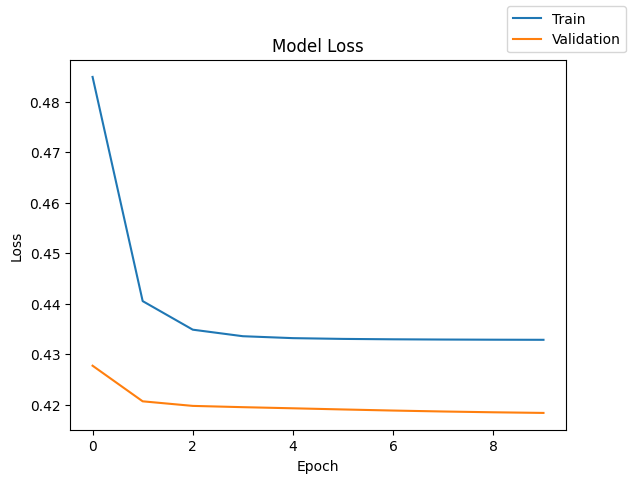

In [382]:
plot(history, 'loss')

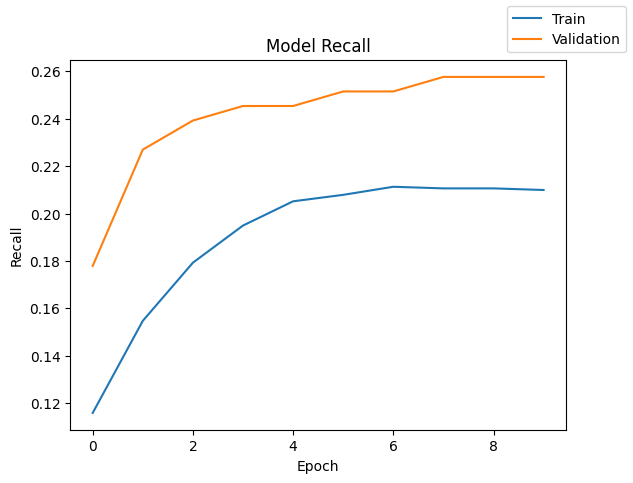

In [383]:
plot(history, 'recall')

25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


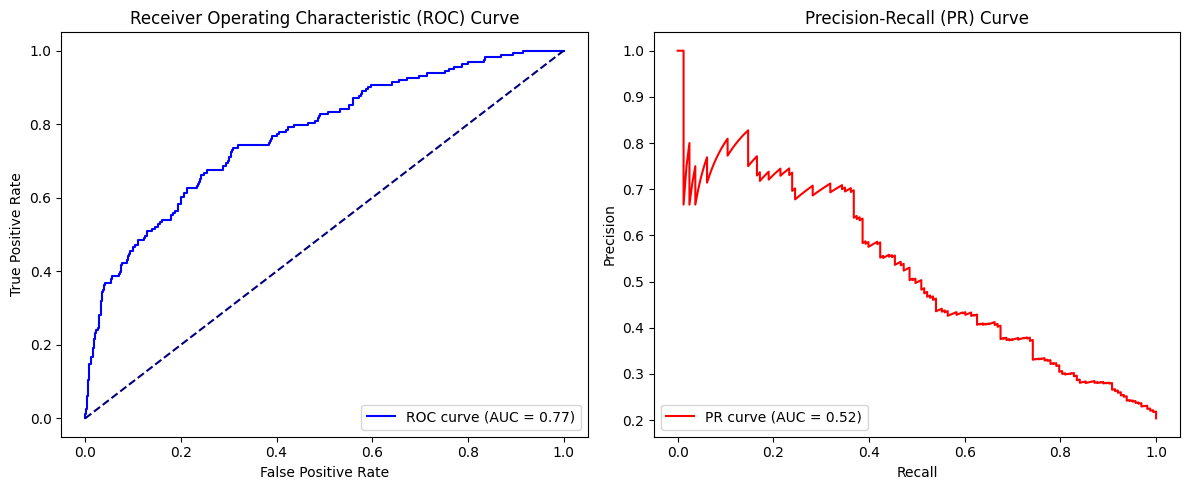

Best Threshold (from PR Curve & F1-score): 0.2564


0.2563828

In [384]:
Find_Best_Threshold(y_val,model_0.predict(X_val))

25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


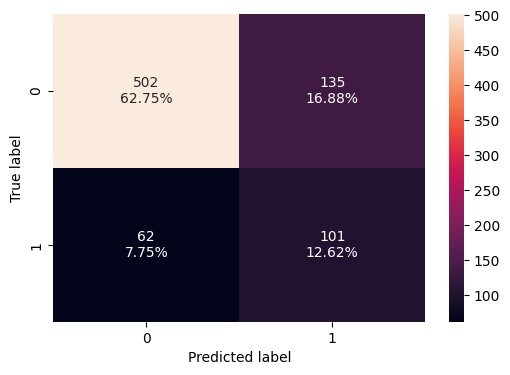

In [385]:
make_confusion_matrix(y_val,model_0.predict(X_val)>0.2564)

In [386]:
y_train_pred = model_0.predict(X_train)
y_train_pred = (y_train_pred > 0.2564)
y_train_pred

y_val_pred = model_0.predict(X_val)
y_val_pred = (y_val_pred > 0.2564)
y_val_pred


model_name = "Model 0 NN with SGD | no hidden layers | batch_size = 32, Epochs = 10"

train_metric_df.loc[model_name] = recall_score(y_train, y_train_pred)
valid_metric_df.loc[model_name] = recall_score(y_val, y_val_pred)


cr = classification_report(y_train, y_train_pred)
print(cr)

225/225 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
              precision    recall  f1-score   support

         0.0       0.89      0.76      0.82      5733
         1.0       0.40      0.62      0.49      1467

    accuracy                           0.73      7200
   macro avg       0.64      0.69      0.65      7200
weighted avg       0.79      0.73      0.75      7200



In [387]:
#clearing session
clear_session()

In [388]:
num_features = X_train.shape[1]
model_1 = Sequential([
    Dense(units=1, activation='sigmoid', input_shape=(num_features,))
])


In [389]:
model_1.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 1)                   │              12 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 12 (48.00 B)

 Trainable params: 12 (48.00 B)

 Non-trainable params: 0 (0.00 B)

In [390]:
optimizer = keras.optimizers.SGD(learning_rate=0.01, momentum=0.9, nesterov=True)
model_1.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=[keras.metrics.Recall()])

In [391]:
batch_size = 32
epochs = 50
start_time = time.time()
history = model_1.fit(X_train, y_train, batch_size=batch_size, epochs=epochs, validation_data=(X_val, y_val))
end_time = time.time()

Epoch 1/50
225/225 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.5180 - recall: 0.1561 - val_loss: 0.4278 - val_recall: 0.1779
Epoch 2/50
225/225 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.4351 - recall: 0.1463 - val_loss: 0.4207 - val_recall: 0.2270
Epoch 3/50
225/225 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.4269 - recall: 0.1787 - val_loss: 0.4198 - val_recall: 0.2393
Epoch 4/50
225/225 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.4249 - recall: 0.2009 - val_loss: 0.4196 - val_recall: 0.2454
Epoch 5/50
225/225 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.4243 - recall: 0.2159 - val_loss: 0.4193 - val_recall: 0.2454
Epoch 6/50
225/225 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.4240 - recall: 0.2219 - val_loss: 0.4191 - val_recall: 0.2515
Epoch 7/50
225/225 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.4239 - recall: 0.2280 - val_loss: 0.4189 - val_recall: 0.2515
Epoch 8/50
225/225 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.4238 - recall: 0.2253 - val_loss: 0.4187 - val_recall: 0.2577
Epoch 9/

In [392]:
print(f'Time taken to train the model: {end_time-start_time} seconds')

Time taken to train the model: 28.060065507888794 seconds


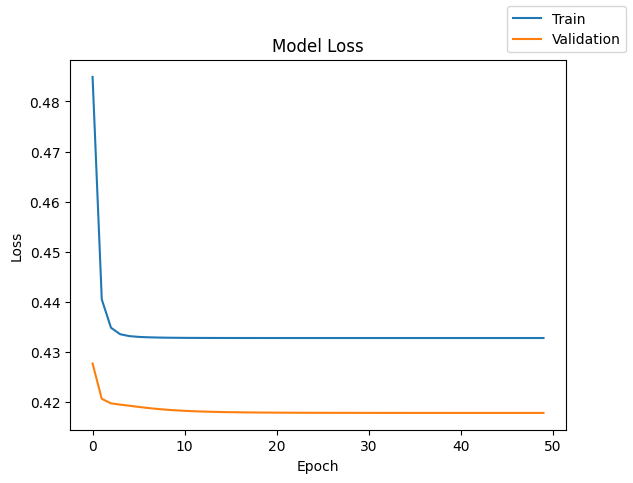

In [393]:
plot(history, 'loss')

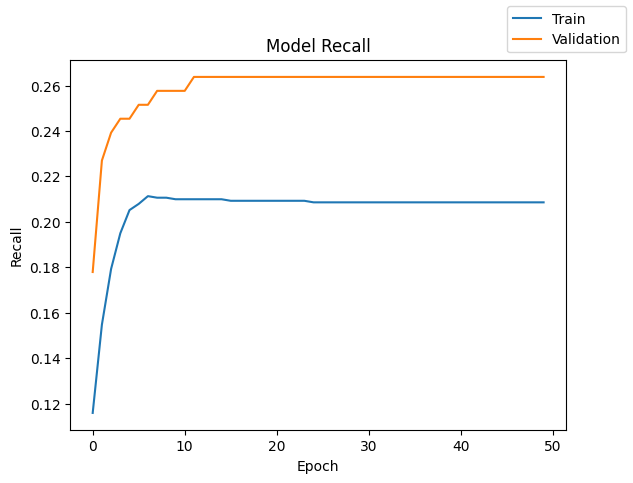

In [394]:
plot(history, 'recall')

25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


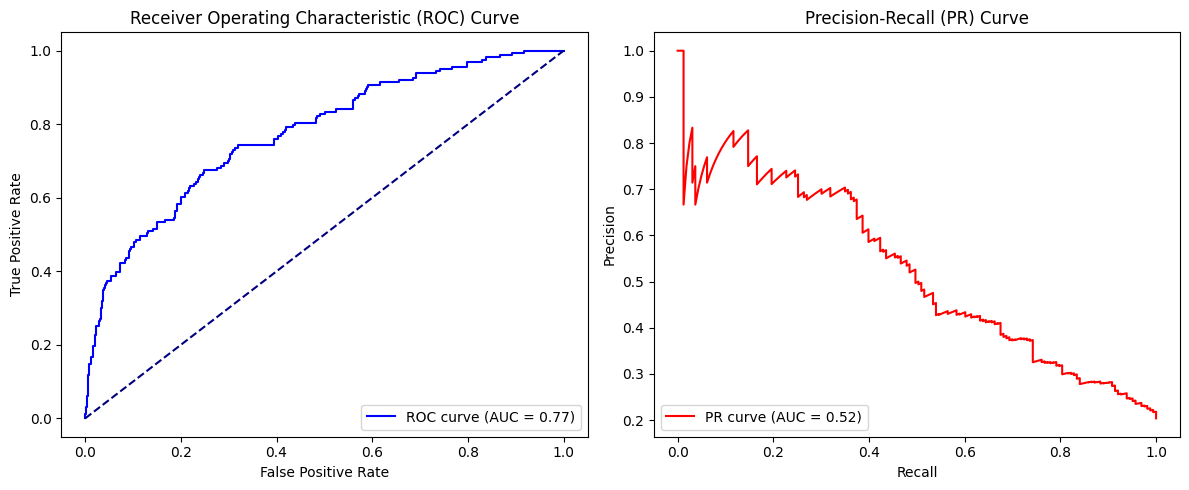

Best Threshold (from PR Curve & F1-score): 0.3373


0.33732167

In [395]:
Find_Best_Threshold(y_val,model_1.predict(X_val))

25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


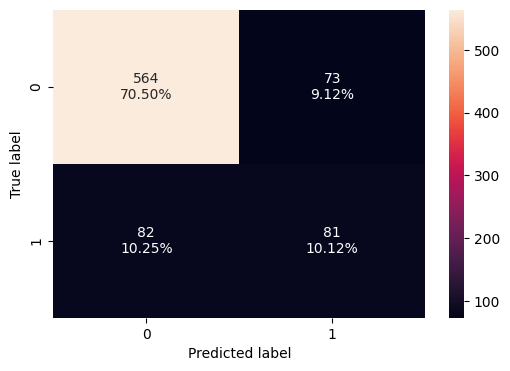

In [396]:
make_confusion_matrix(y_val,model_1.predict(X_val)>0.3373)

In [397]:
y_train_pred = model_1.predict(X_train)
y_train_pred = (y_train_pred > 0.3373)
y_train_pred

y_val_pred = model_1.predict(X_val)
y_val_pred = (y_val_pred > 0.3373)
y_val_pred


model_name = "Model 1 NN with SGD | no hidden layers | batch_size = 32, Epochs = 50"

train_metric_df.loc[model_name] = recall_score(y_train, y_train_pred)
valid_metric_df.loc[model_name] = recall_score(y_val, y_val_pred)


cr = classification_report(y_train, y_train_pred)
print(cr)

225/225 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
              precision    recall  f1-score   support

         0.0       0.86      0.87      0.87      5733
         1.0       0.48      0.47      0.47      1467

    accuracy                           0.79      7200
   macro avg       0.67      0.67      0.67      7200
weighted avg       0.79      0.79      0.79      7200



In [398]:
#clearing session
clear_session()


In [399]:
num_features = X_train.shape[1]
model_2 = Sequential([
    Dense(units=1, activation='sigmoid', input_shape=(num_features,))
])
model_2.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 1)                   │              12 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 12 (48.00 B)

 Trainable params: 12 (48.00 B)

 Non-trainable params: 0 (0.00 B)

In [400]:
optimizer = keras.optimizers.SGD(learning_rate=0.01, momentum=0.9, nesterov=True)
model_2.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=[keras.metrics.Recall()])

In [401]:
batch_size = 64
epochs = 50
start_time = time.time()
history = model_2.fit(X_train, y_train, batch_size=batch_size, epochs=epochs, validation_data=(X_val, y_val))
end_time = time.time()


Epoch 1/50
113/113 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.5509 - recall: 0.1926 - val_loss: 0.4447 - val_recall: 0.1166
Epoch 2/50
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.4516 - recall: 0.1254 - val_loss: 0.4254 - val_recall: 0.1656
Epoch 3/50
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.4358 - recall: 0.1380 - val_loss: 0.4202 - val_recall: 0.1963
Epoch 4/50
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.4292 - recall: 0.1629 - val_loss: 0.4184 - val_recall: 0.2147
Epoch 5/50
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.4262 - recall: 0.1746 - val_loss: 0.4177 - val_recall: 0.2270
Epoch 6/50
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.4248 - recall: 0.1913 - val_loss: 0.4174 - val_recall: 0.2393
Epoch 7/50
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.4240 - recall: 0.2025 - val_loss: 0.4172 - val_recall: 0.2393
Epoch 8/50
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.4236 - recall: 0.2080 - val_loss: 0.4171 - val_recall: 0.2393
Epoch 9/

In [402]:
print(f'Time taken to train the model: {end_time-start_time} seconds')

Time taken to train the model: 17.364168882369995 seconds


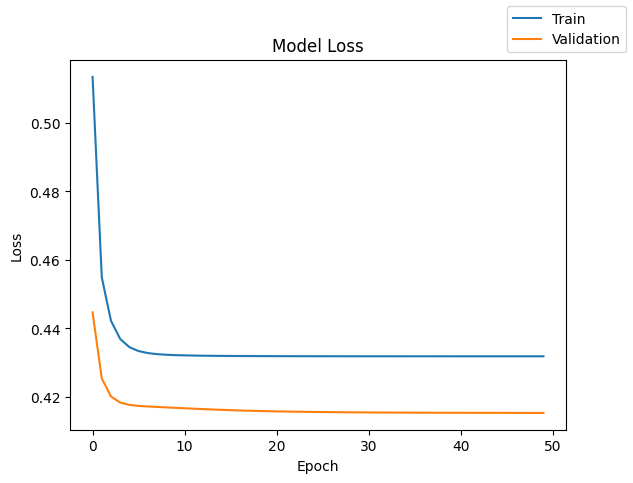

In [403]:
plot(history, 'loss')

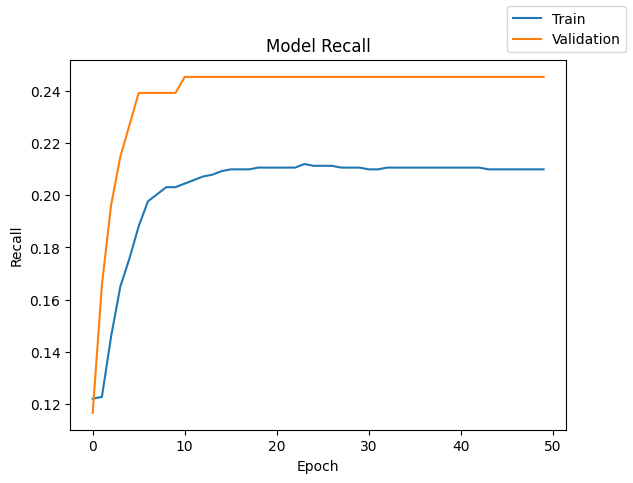

In [404]:
plot(history, 'recall')

25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


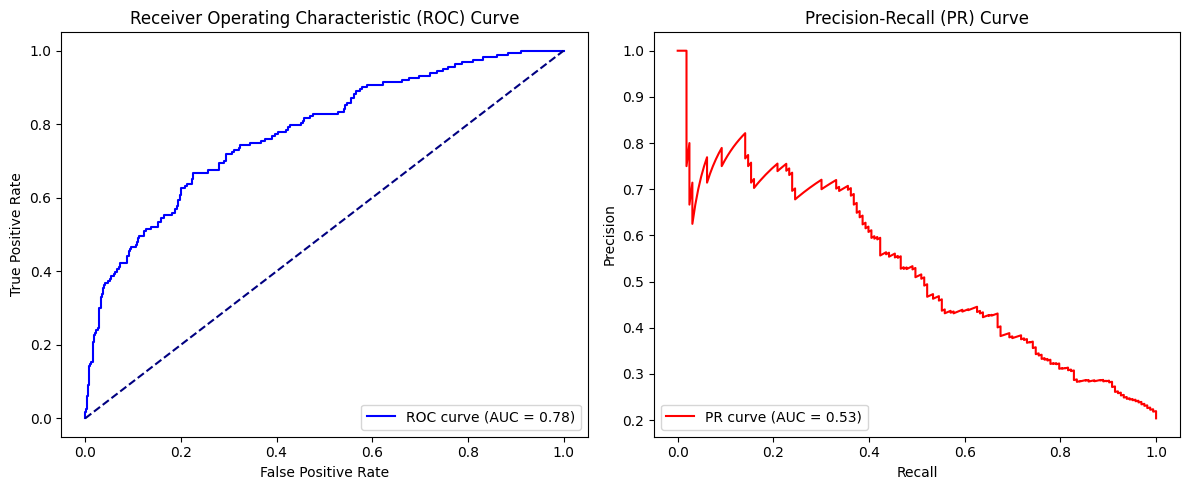

Best Threshold (from PR Curve & F1-score): 0.2330


0.23298737

In [405]:
Find_Best_Threshold(y_val,model_2.predict(X_val))

25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


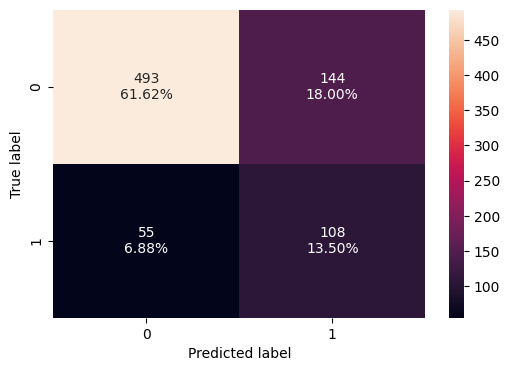

In [406]:
make_confusion_matrix(y_val,model_2.predict(X_val)>0.2330)

In [407]:
y_train_pred = model_2.predict(X_train)
y_train_pred = (y_train_pred > 0.2330)
y_train_pred

y_val_pred = model_2.predict(X_val)
y_val_pred = (y_val_pred > 0.2330)
y_val_pred


model_name = "Model 2 NN with SGD | no hidden layers | batch_size = 64, Epochs = 50"

train_metric_df.loc[model_name] = recall_score(y_train, y_train_pred)
valid_metric_df.loc[model_name] = recall_score(y_val, y_val_pred)


cr = classification_report(y_train, y_train_pred)
print(cr)

225/225 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
              precision    recall  f1-score   support

         0.0       0.89      0.74      0.81      5733
         1.0       0.39      0.64      0.49      1467

    accuracy                           0.72      7200
   macro avg       0.64      0.69      0.65      7200
weighted avg       0.79      0.72      0.74      7200



In [408]:
#clearing session
clear_session()


In [409]:
num_features = X_train.shape[1]
model_3 = Sequential([
    Dense(units=1, activation='sigmoid', input_shape=(num_features,))
])
model_3.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 1)                   │              12 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 12 (48.00 B)

 Trainable params: 12 (48.00 B)

 Non-trainable params: 0 (0.00 B)

In [410]:
optimizer = keras.optimizers.SGD(learning_rate=0.01, momentum=0.9, nesterov=True)
model_3.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=[keras.metrics.Recall()])

In [411]:
batch_size = 64
epochs = 100
start_time = time.time()
history = model_3.fit(X_train, y_train, batch_size=batch_size, epochs=epochs, validation_data=(X_val, y_val))
end_time = time.time()


Epoch 1/100
113/113 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.5509 - recall: 0.1926 - val_loss: 0.4447 - val_recall: 0.1166
Epoch 2/100
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.4516 - recall: 0.1254 - val_loss: 0.4254 - val_recall: 0.1656
Epoch 3/100
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.4358 - recall: 0.1380 - val_loss: 0.4202 - val_recall: 0.1963
Epoch 4/100
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.4292 - recall: 0.1629 - val_loss: 0.4184 - val_recall: 0.2147
Epoch 5/100
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.4262 - recall: 0.1746 - val_loss: 0.4177 - val_recall: 0.2270
Epoch 6/100
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.4248 - recall: 0.1913 - val_loss: 0.4174 - val_recall: 0.2393
Epoch 7/100
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.4240 - recall: 0.2025 - val_loss: 0.4172 - val_recall: 0.2393
Epoch 8/100
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.4236 - recall: 0.2080 - val_loss: 0.4171 - val_recall: 0.2393


In [412]:
print(f'Time taken to train the model: {end_time-start_time} seconds')

Time taken to train the model: 33.31083846092224 seconds


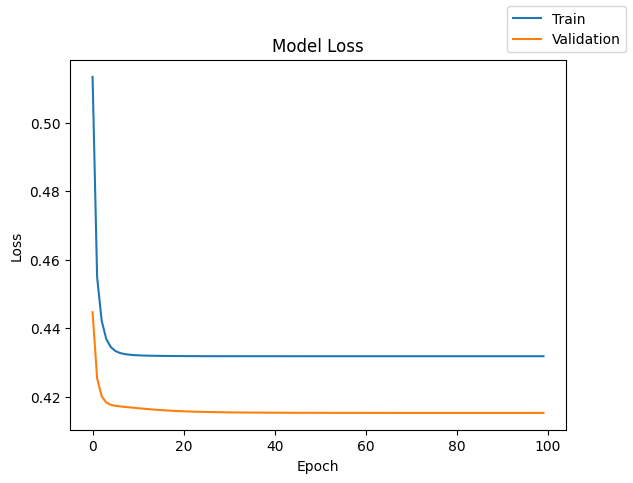

In [413]:
plot(history, 'loss')

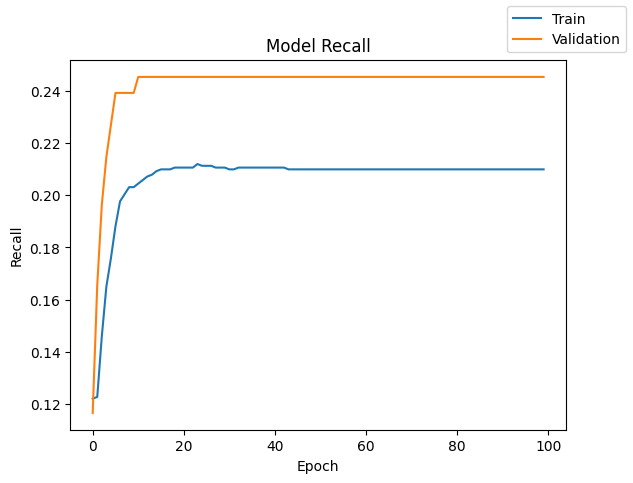

In [414]:
plot(history, 'recall')

25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


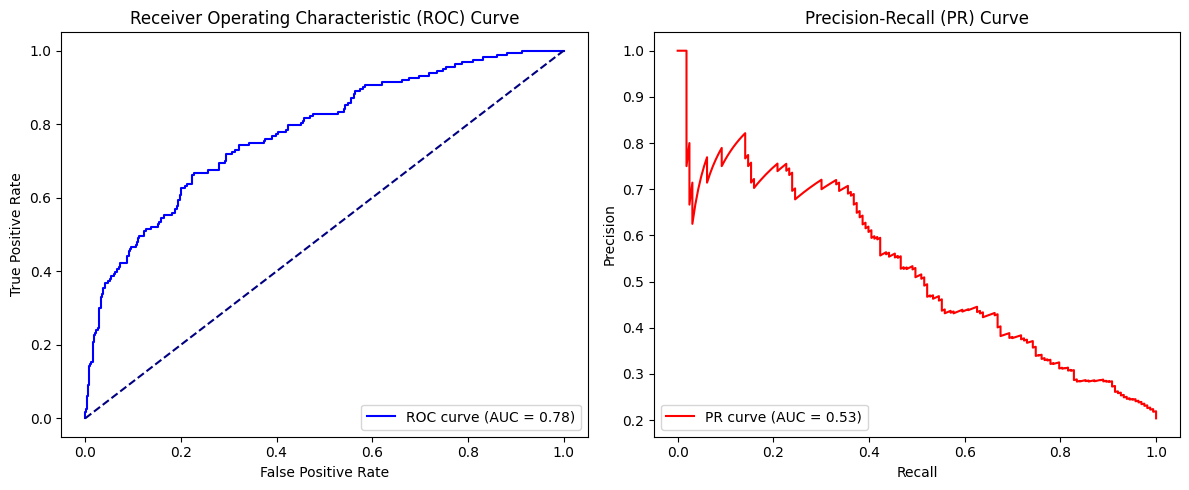

Best Threshold (from PR Curve & F1-score): 0.2337


0.23369122

In [415]:
Find_Best_Threshold(y_val,model_3.predict(X_val))

25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


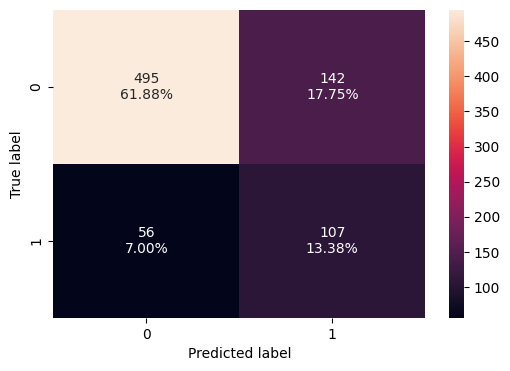

In [416]:
make_confusion_matrix(y_val,model_3.predict(X_val)>0.2337)

In [417]:
y_train_pred = model_3.predict(X_train)
y_train_pred = (y_train_pred > 0.2337)
y_train_pred

y_val_pred = model_3.predict(X_val)
y_val_pred = (y_val_pred > 0.2337)
y_val_pred


model_name = "Model 3 NN with SGD | no hidden layers | batch_size = 64, Epochs = 100"

train_metric_df.loc[model_name] = recall_score(y_train, y_train_pred)
valid_metric_df.loc[model_name] = recall_score(y_val, y_val_pred)


cr = classification_report(y_train, y_train_pred)
print(cr)

225/225 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
              precision    recall  f1-score   support

         0.0       0.89      0.74      0.81      5733
         1.0       0.39      0.64      0.49      1467

    accuracy                           0.72      7200
   macro avg       0.64      0.69      0.65      7200
weighted avg       0.79      0.72      0.74      7200



In [418]:
#clearing session
clear_session()


In [419]:
num_features = X_train.shape[1]
model_4 = Sequential([
    Dense(units=1, activation='sigmoid', input_shape=(num_features,))
])
model_4.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 1)                   │              12 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 12 (48.00 B)

 Trainable params: 12 (48.00 B)

 Non-trainable params: 0 (0.00 B)

In [420]:
optimizer = keras.optimizers.SGD(learning_rate=0.01, momentum=0.9, nesterov=True)
model_4.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=[keras.metrics.Recall()])

In [421]:
batch_size = 32
epochs = 100
start_time = time.time()
history = model_4.fit(X_train, y_train, batch_size=batch_size, epochs=epochs, validation_data=(X_val, y_val))
end_time = time.time()


Epoch 1/100
225/225 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.5180 - recall: 0.1561 - val_loss: 0.4278 - val_recall: 0.1779
Epoch 2/100
225/225 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.4351 - recall: 0.1463 - val_loss: 0.4207 - val_recall: 0.2270
Epoch 3/100
225/225 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.4269 - recall: 0.1787 - val_loss: 0.4198 - val_recall: 0.2393
Epoch 4/100
225/225 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.4249 - recall: 0.2009 - val_loss: 0.4196 - val_recall: 0.2454
Epoch 5/100
225/225 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.4243 - recall: 0.2159 - val_loss: 0.4193 - val_recall: 0.2454
Epoch 6/100
225/225 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.4240 - recall: 0.2219 - val_loss: 0.4191 - val_recall: 0.2515
Epoch 7/100
225/225 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.4239 - recall: 0.2280 - val_loss: 0.4189 - val_recall: 0.2515
Epoch 8/100
225/225 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.4238 - recall: 0.2253 - val_loss: 0.4187 - val_recall: 0.2577


In [422]:
print(f'Time taken to train the model: {end_time-start_time} seconds')

Time taken to train the model: 55.14367198944092 seconds


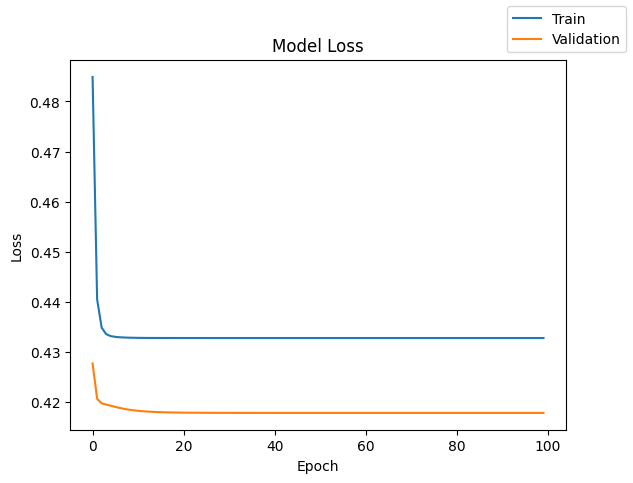

In [423]:
plot(history, 'loss')

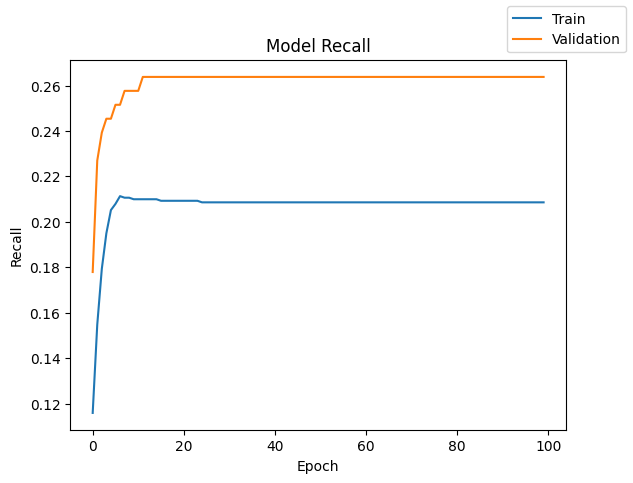

In [424]:
plot(history, 'recall')

25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


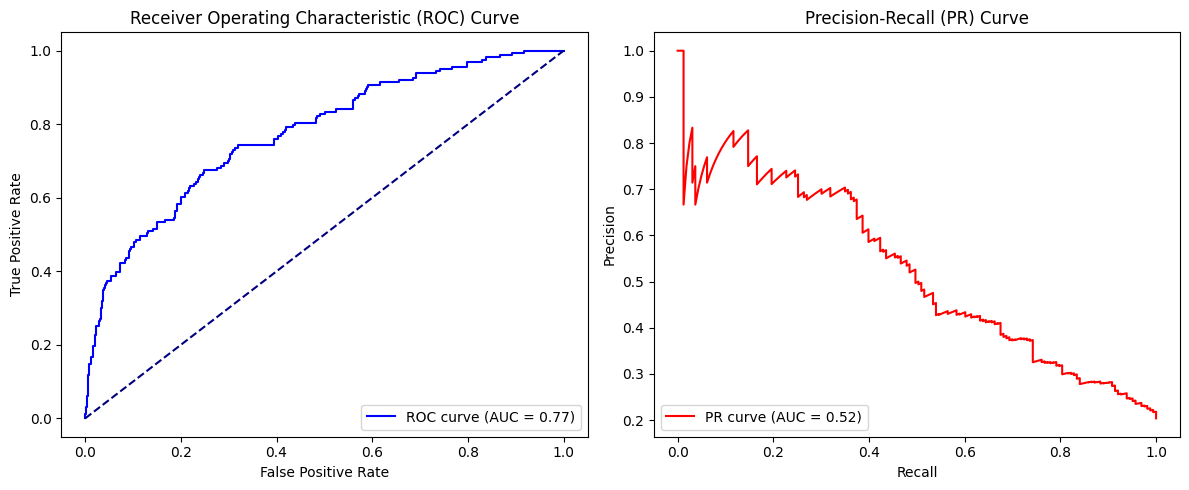

Best Threshold (from PR Curve & F1-score): 0.3373


0.337323

In [425]:
Find_Best_Threshold(y_val,model_4.predict(X_val))

25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


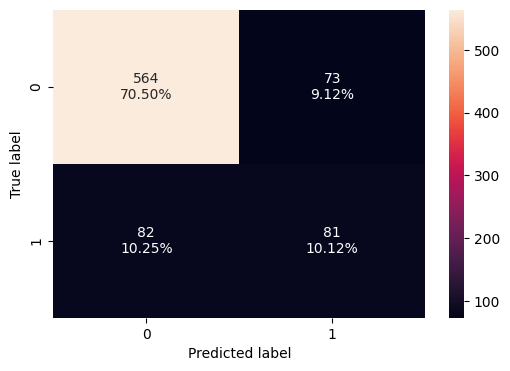

In [426]:
make_confusion_matrix(y_val,model_4.predict(X_val)>0.3373)

In [427]:
y_train_pred = model_4.predict(X_train)
y_train_pred = (y_train_pred > 0.3373)
y_train_pred

y_val_pred = model_4.predict(X_val)
y_val_pred = (y_val_pred > 0.3373)
y_val_pred


model_name = "Model 4 NN with SGD | no hidden layers | batch_size = 32, Epochs = 100"

train_metric_df.loc[model_name] = recall_score(y_train, y_train_pred)
valid_metric_df.loc[model_name] = recall_score(y_val, y_val_pred)


cr = classification_report(y_train, y_train_pred)
print(cr)

225/225 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
              precision    recall  f1-score   support

         0.0       0.86      0.87      0.87      5733
         1.0       0.48      0.47      0.47      1467

    accuracy                           0.79      7200
   macro avg       0.67      0.67      0.67      7200
weighted avg       0.79      0.79      0.79      7200



In [428]:
#adding hidden layer
#clearing session
clear_session()


In [429]:
num_features = X_train.shape[1]
model_5 = Sequential([
    Dense(32, activation='relu', input_shape=(num_features,)),
    Dense(1, activation='sigmoid')
])
model_5.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 32)                  │             384 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 417 (1.63 KB)

 Trainable params: 417 (1.63 KB)

 Non-trainable params: 0 (0.00 B)

In [430]:
optimizer = keras.optimizers.SGD(learning_rate=0.01, momentum=0.9, nesterov=True)
model_5.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=[keras.metrics.Recall()])

In [431]:
batch_size = 32
epochs = 100
start_time = time.time()
history = model_5.fit(X_train, y_train, batch_size=batch_size, epochs=epochs, validation_data=(X_val, y_val))
end_time = time.time()


Epoch 1/100
225/225 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.4854 - recall: 0.1567 - val_loss: 0.4126 - val_recall: 0.1902
Epoch 2/100
225/225 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.4202 - recall: 0.1850 - val_loss: 0.4064 - val_recall: 0.2577
Epoch 3/100
225/225 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.4109 - recall: 0.2285 - val_loss: 0.4024 - val_recall: 0.3129
Epoch 4/100
225/225 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.4051 - recall: 0.2515 - val_loss: 0.3992 - val_recall: 0.3313
Epoch 5/100
225/225 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.3997 - recall: 0.2675 - val_loss: 0.3957 - val_recall: 0.3374
Epoch 6/100
225/225 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.3944 - recall: 0.2796 - val_loss: 0.3924 - val_recall: 0.3374
Epoch 7/100
225/225 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.3894 - recall: 0.2964 - val_loss: 0.3888 - val_recall: 0.3681
Epoch 8/100
225/225 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.3850 - recall: 0.3190 - val_loss: 0.3849 - val_recall: 0.3804


In [432]:
print(f'Time taken to train the model: {end_time-start_time} seconds')

Time taken to train the model: 55.848283767700195 seconds


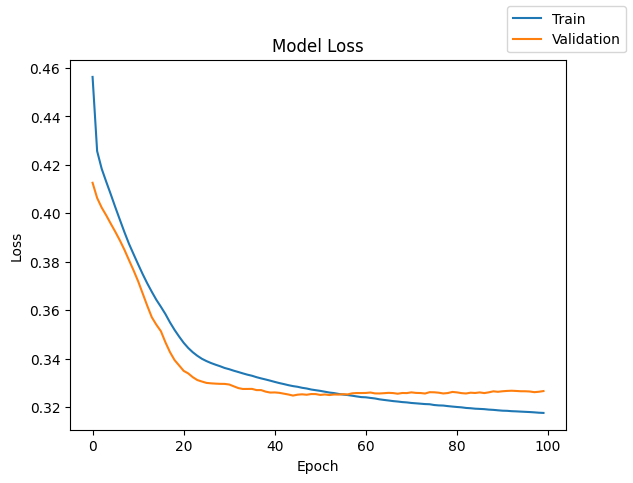

In [433]:
plot(history, 'loss')

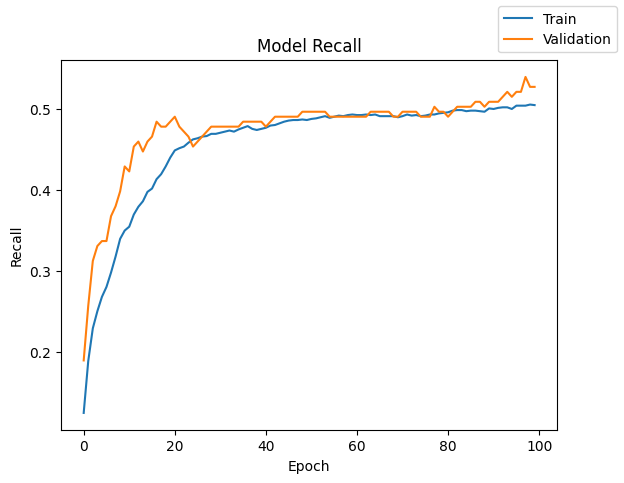

In [434]:
plot(history, 'recall')

25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step  


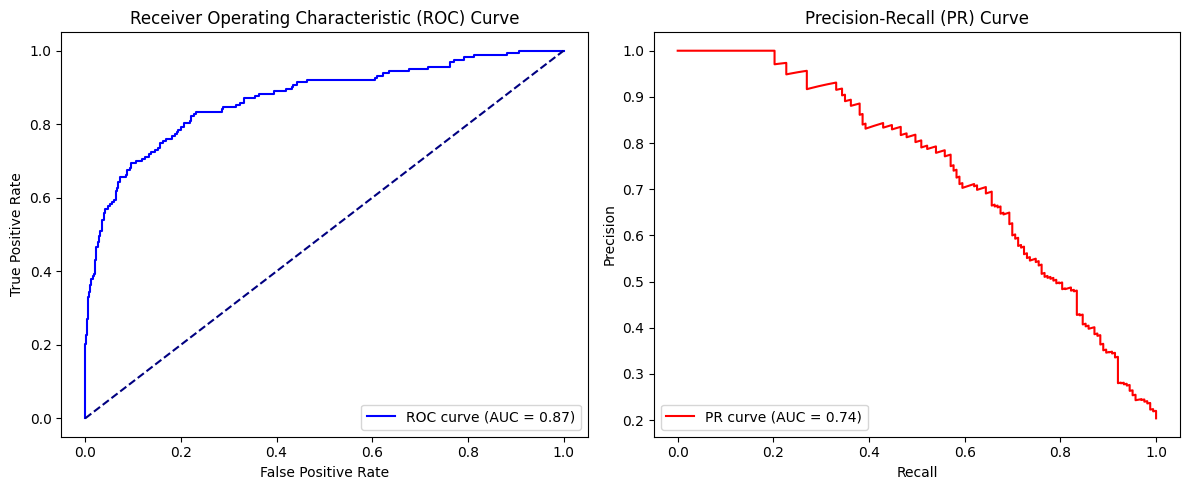

Best Threshold (from PR Curve & F1-score): 0.3884


0.38842478

In [435]:
Find_Best_Threshold(y_val,model_5.predict(X_val))

25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


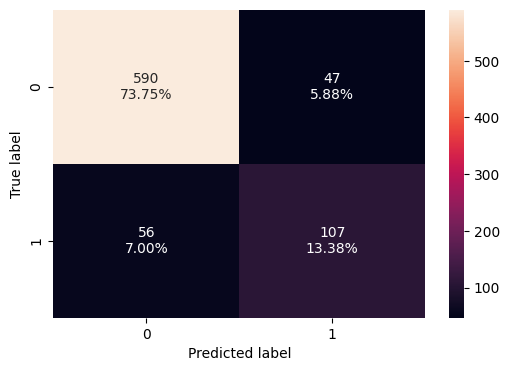

In [436]:
make_confusion_matrix(y_val,model_5.predict(X_val)>0.3884)

In [437]:
y_train_pred = model_5.predict(X_train)
y_train_pred = (y_train_pred > 0.3884)

y_val_pred = model_5.predict(X_val)
y_val_pred = (y_val_pred > 0.3884)

model_name = "Model 5 NN with SGD | one hidden layer | batch_size = 32, Epochs = 100"

train_metric_df.loc[model_name] = recall_score(y_train, y_train_pred)
valid_metric_df.loc[model_name] = recall_score(y_val, y_val_pred)

cr = classification_report(y_train, y_train_pred)
print(cr)

225/225 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
              precision    recall  f1-score   support

         0.0       0.91      0.91      0.91      5733
         1.0       0.64      0.64      0.64      1467

    accuracy                           0.85      7200
   macro avg       0.77      0.78      0.77      7200
weighted avg       0.85      0.85      0.85      7200



In [438]:
#adding two hidden layer
#clearing session
clear_session()


In [439]:
num_features = X_train.shape[1]
model_6 = Sequential([
    Dense(32, activation='relu', input_shape=(num_features,)),
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid')
])
model_6.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 32)                  │             384 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 16)                  │             528 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 1)                   │              17 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 929 (3.63 KB)

 Trainable params: 929 (3.63 KB)

 Non-trainable params: 0 (0.00 B)

In [440]:
optimizer = keras.optimizers.SGD(learning_rate=0.01, momentum=0.9, nesterov=True)
model_6.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=[keras.metrics.Recall()])

In [441]:
batch_size = 32
epochs = 100
start_time = time.time()
history = model_6.fit(X_train, y_train, batch_size=batch_size, epochs=epochs, validation_data=(X_val, y_val))
end_time = time.time()

Epoch 1/100
225/225 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.4851 - recall: 0.0069 - val_loss: 0.4244 - val_recall: 0.0491
Epoch 2/100
225/225 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.4241 - recall: 0.0997 - val_loss: 0.4150 - val_recall: 0.1779
Epoch 3/100
225/225 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.4147 - recall: 0.1651 - val_loss: 0.4112 - val_recall: 0.2270
Epoch 4/100
225/225 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.4073 - recall: 0.2110 - val_loss: 0.4062 - val_recall: 0.2761
Epoch 5/100
225/225 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.4004 - recall: 0.2697 - val_loss: 0.4015 - val_recall: 0.3129
Epoch 6/100
225/225 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.3934 - recall: 0.2941 - val_loss: 0.3956 - val_recall: 0.3252
Epoch 7/100
225/225 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.3858 - recall: 0.3125 - val_loss: 0.3876 - val_recall: 0.3558
Epoch 8/100
225/225 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.3778 - recall: 0.3353 - val_loss: 0.3750 - val_recall: 0.3620


In [442]:
print(f'Time taken to train the model: {end_time-start_time} seconds')

Time taken to train the model: 56.72203063964844 seconds


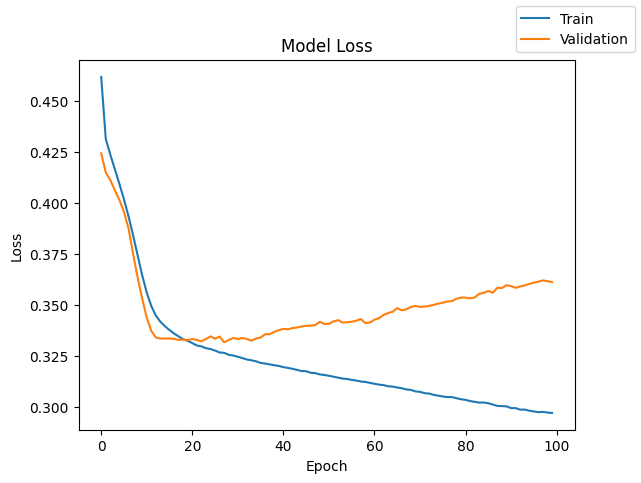

In [443]:
plot(history, 'loss')


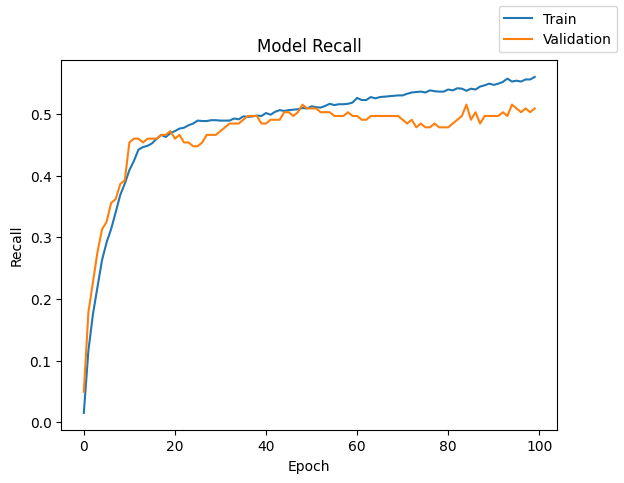

In [444]:
plot(history, 'recall')

25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step  


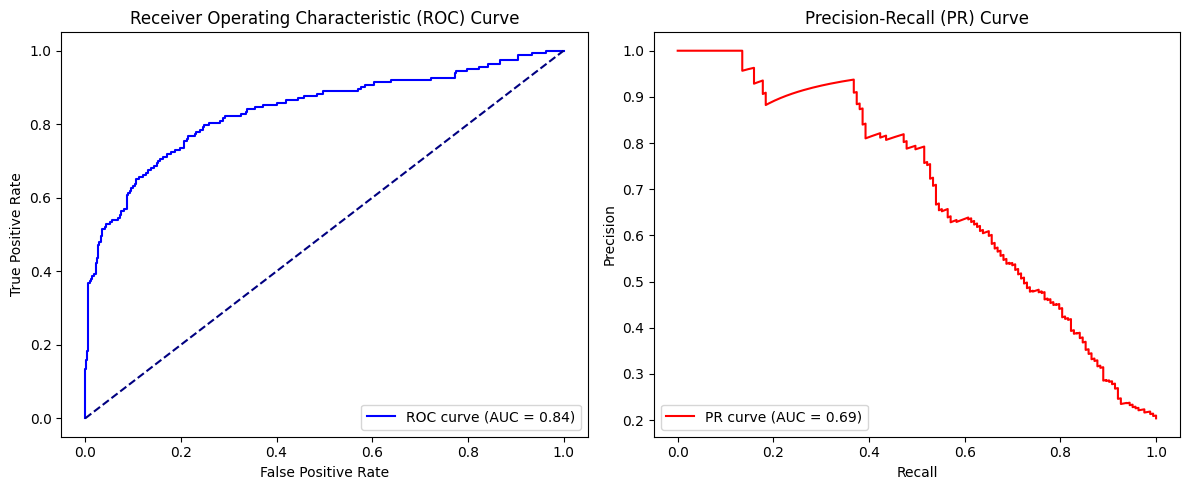

Best Threshold (from PR Curve & F1-score): 0.3298


0.32979763

In [445]:
Find_Best_Threshold(y_val,model_6.predict(X_val))

25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


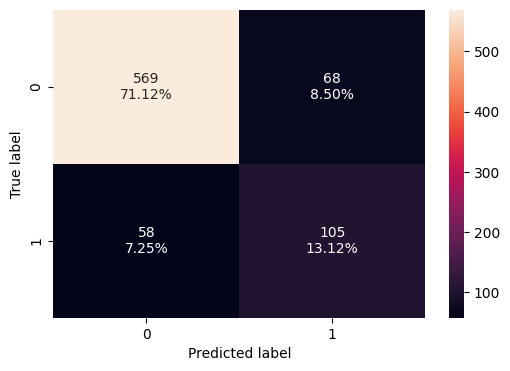

In [446]:
make_confusion_matrix(y_val,model_6.predict(X_val)>0.3298)

In [447]:
y_train_pred = model_6.predict(X_train)
y_train_pred = (y_train_pred > 0.3298)

y_val_pred = model_6.predict(X_val)
y_val_pred = (y_val_pred > 0.3298)

model_name = "Model 6 NN with SGD | two hidden layer | batch_size = 32, Epochs = 100"

train_metric_df.loc[model_name] = recall_score(y_train, y_train_pred)
valid_metric_df.loc[model_name] = recall_score(y_val, y_val_pred)

cr = classification_report(y_train, y_train_pred)
print(cr)

225/225 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
              precision    recall  f1-score   support

         0.0       0.92      0.90      0.91      5733
         1.0       0.65      0.71      0.68      1467

    accuracy                           0.86      7200
   macro avg       0.79      0.80      0.79      7200
weighted avg       0.87      0.86      0.86      7200



In [448]:
#adding two hidden layer
#clearing session
clear_session()


In [449]:
num_features = X_train.shape[1]
model_7 = Sequential([
    Dense(32, activation='relu', input_shape=(num_features,)),
    Dense(16, activation='relu'),
    Dense(8, activation='relu'),
    Dense(1, activation='sigmoid')
])
model_7.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 32)                  │             384 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 16)                  │             528 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 8)                   │             136 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 1)                   │               9 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,057 (4.13 KB)

 Trainable params: 1,057 (4.13 KB)

 Non-trainable params: 0 (0.00 B)

In [450]:
optimizer = keras.optimizers.SGD(learning_rate=0.01, momentum=0.9, nesterov=True)
model_7.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=[keras.metrics.Recall()])

In [451]:
batch_size = 32
epochs = 100
start_time = time.time()
history = model_7.fit(X_train, y_train, batch_size=batch_size, epochs=epochs, validation_data=(X_val, y_val))
end_time = time.time()

Epoch 1/100
225/225 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.5822 - recall: 0.1972 - val_loss: 0.4807 - val_recall: 0.0061
Epoch 2/100
225/225 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.4695 - recall: 0.0321 - val_loss: 0.4243 - val_recall: 0.2883
Epoch 3/100
225/225 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.4316 - recall: 0.2070 - val_loss: 0.4081 - val_recall: 0.3804
Epoch 4/100
225/225 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.4132 - recall: 0.2597 - val_loss: 0.3932 - val_recall: 0.3926
Epoch 5/100
225/225 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.3971 - recall: 0.3190 - val_loss: 0.3798 - val_recall: 0.4172
Epoch 6/100
225/225 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.3828 - recall: 0.3600 - val_loss: 0.3656 - val_recall: 0.3988
Epoch 7/100
225/225 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.3728 - recall: 0.3800 - val_loss: 0.3556 - val_recall: 0.4233
Epoch 8/100
225/225 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.3655 - recall: 0.3968 - val_loss: 0.3468 - val_recall: 0.4172


In [452]:
print(f'Time taken to train the model: {end_time-start_time} seconds')

Time taken to train the model: 58.52146506309509 seconds


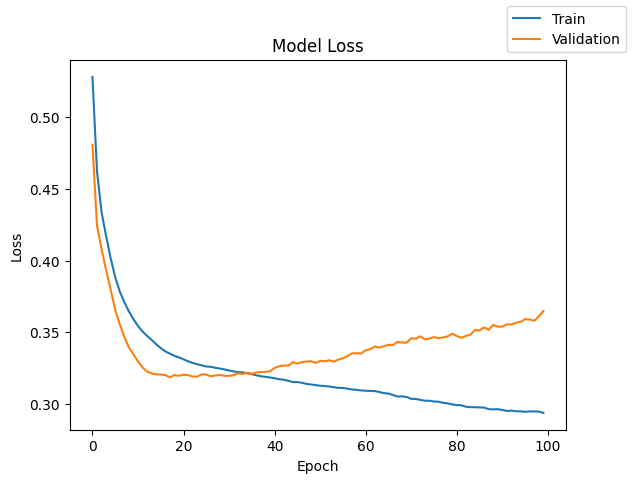

In [453]:
plot(history, 'loss')

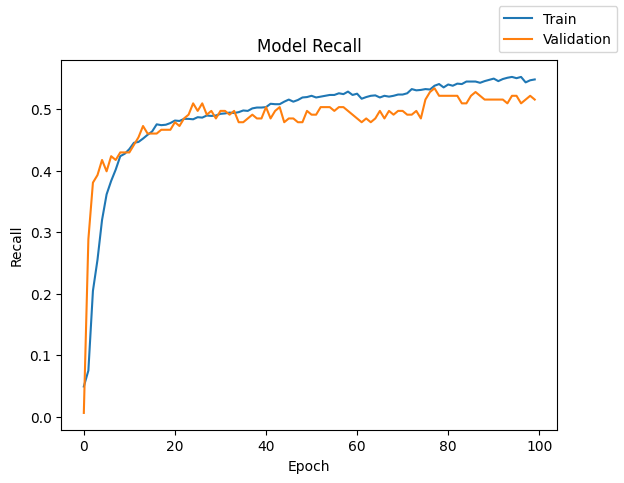

In [454]:
plot(history, 'recall')

25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step  


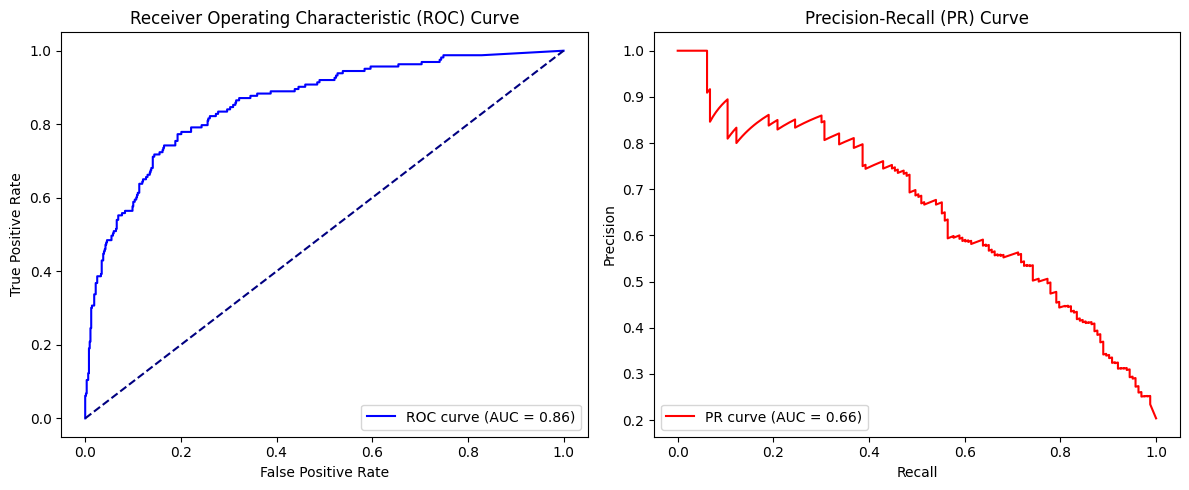

Best Threshold (from PR Curve & F1-score): 0.2776


0.27756396

In [455]:
Find_Best_Threshold(y_val,model_7.predict(X_val))

25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


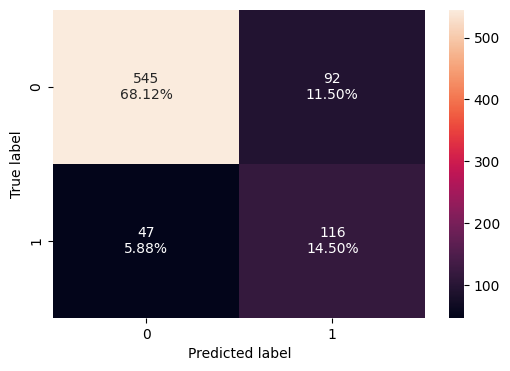

In [456]:
make_confusion_matrix(y_val,model_7.predict(X_val)>0.2776)

In [457]:
y_train_pred = model_7.predict(X_train)
y_train_pred = (y_train_pred > 0.2776)

y_val_pred = model_7.predict(X_val)
y_val_pred = (y_val_pred > 0.2776)

model_name = "Model 7 NN with SGD | three hidden layer | batch_size = 32, Epochs = 100"

train_metric_df.loc[model_name] = recall_score(y_train, y_train_pred)
valid_metric_df.loc[model_name] = recall_score(y_val, y_val_pred)

cr = classification_report(y_train, y_train_pred)
print(cr)

225/225 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
              precision    recall  f1-score   support

         0.0       0.93      0.86      0.89      5733
         1.0       0.58      0.76      0.66      1467

    accuracy                           0.84      7200
   macro avg       0.75      0.81      0.77      7200
weighted avg       0.86      0.84      0.84      7200



In [458]:
#with batch size 64
# clearing session
clear_session()

In [459]:
num_features = X_train.shape[1]
model_8 = Sequential([
    Dense(32, activation='relu', input_shape=(num_features,)),
    Dense(16, activation='relu'),
    Dense(8, activation='relu'),
    Dense(1, activation='sigmoid')
])
model_8.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 32)                  │             384 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 16)                  │             528 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 8)                   │             136 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 1)                   │               9 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,057 (4.13 KB)

 Trainable params: 1,057 (4.13 KB)

 Non-trainable params: 0 (0.00 B)

In [460]:
optimizer = keras.optimizers.SGD(learning_rate=0.01, momentum=0.9, nesterov=True)
model_8.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=[keras.metrics.Recall()])

In [461]:
batch_size = 64
epochs = 100
start_time = time.time()
history = model_8.fit(X_train, y_train, batch_size=batch_size, epochs=epochs, validation_data=(X_val, y_val))
end_time = time.time()

Epoch 1/100
113/113 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 0.6273 - recall: 0.2923 - val_loss: 0.5048 - val_recall: 0.0000e+00
Epoch 2/100
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.4980 - recall: 0.0000e+00 - val_loss: 0.4822 - val_recall: 0.0000e+00
Epoch 3/100
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.4766 - recall: 0.0056 - val_loss: 0.4408 - val_recall: 0.0736
Epoch 4/100
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.4493 - recall: 0.1212 - val_loss: 0.4214 - val_recall: 0.1963
Epoch 5/100
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.4328 - recall: 0.1947 - val_loss: 0.4108 - val_recall: 0.2883
Epoch 6/100
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.4214 - recall: 0.2356 - val_loss: 0.4013 - val_recall: 0.3313
Epoch 7/100
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.4117 - recall: 0.2625 - val_loss: 0.3930 - val_recall: 0.3804
Epoch 8/100
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.4022 - recall: 0.2892 - val_loss: 0.3868 - val_re

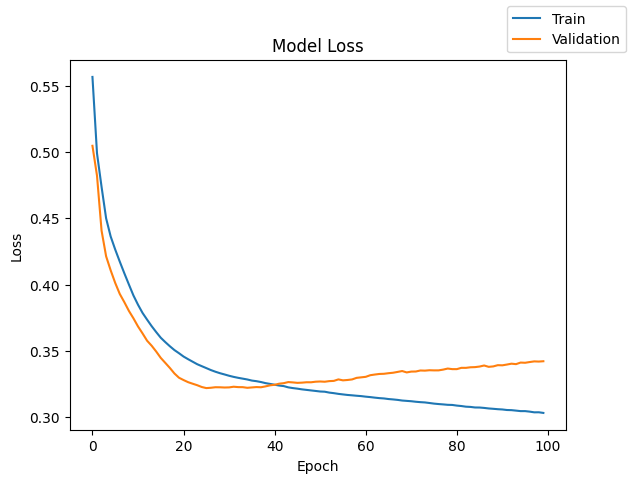

In [462]:
plot(history, 'loss')

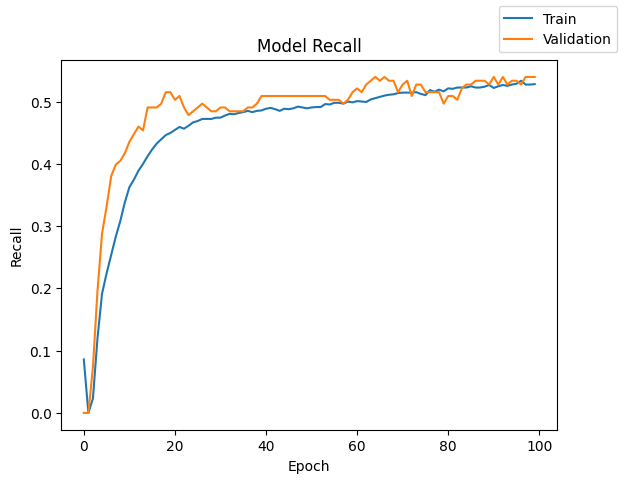

In [463]:
plot(history, 'recall')

25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step  


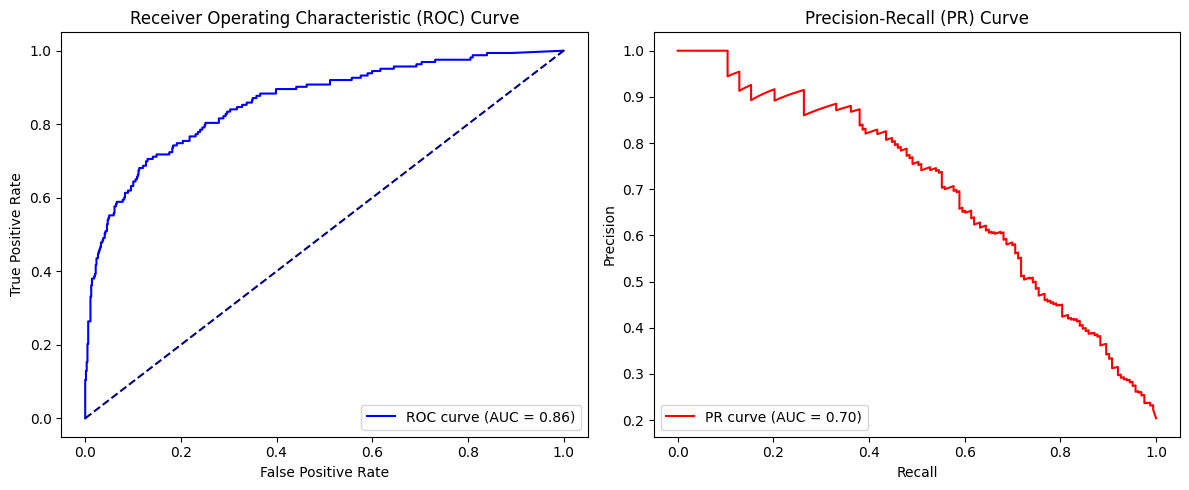

Best Threshold (from PR Curve & F1-score): 0.3113


0.3112946

In [464]:
Find_Best_Threshold(y_val,model_8.predict(X_val))

25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


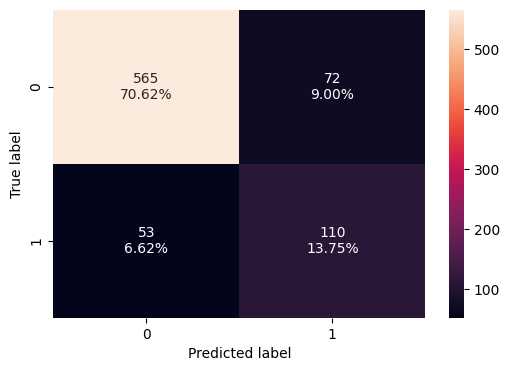

In [465]:
make_confusion_matrix(y_val,model_8.predict(X_val)>0.3113)

In [466]:
y_train_pred = model_8.predict(X_train)
y_train_pred = (y_train_pred > 0.3113)

y_val_pred = model_8.predict(X_val)
y_val_pred = (y_val_pred > 0.3113)

model_name = "Model 8 NN with SGD | three hidden layer | batch_size = 64, Epochs = 100"

train_metric_df.loc[model_name] = recall_score(y_train, y_train_pred)
valid_metric_df.loc[model_name] = recall_score(y_val, y_val_pred)

cr = classification_report(y_train, y_train_pred)
print(cr)

225/225 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
              precision    recall  f1-score   support

         0.0       0.93      0.88      0.90      5733
         1.0       0.61      0.73      0.66      1467

    accuracy                           0.85      7200
   macro avg       0.77      0.80      0.78      7200
weighted avg       0.86      0.85      0.85      7200



# Neural Network with Adam Optimizer

In [467]:
#clearing session
clear_session()

In [468]:
num_features = X_train.shape[1]
model_9 = Sequential([
    Dense(32, activation='relu', input_shape=(num_features,)),
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid')
])

model_9.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 32)                  │             384 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 16)                  │             528 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 1)                   │              17 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 929 (3.63 KB)

 Trainable params: 929 (3.63 KB)

 Non-trainable params: 0 (0.00 B)

In [469]:
optimizer = keras.optimizers.Adam(learning_rate=0.0005)
model_9.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=[keras.metrics.Recall()])

In [470]:
batch_size = 32
epochs = 100
start_time = time.time()
history = model_9.fit(X_train, y_train, batch_size=batch_size, epochs=epochs, validation_data=(X_val, y_val))
end_time = time.time()

Epoch 1/100
225/225 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.5284 - recall: 0.0193 - val_loss: 0.4546 - val_recall: 0.0000e+00
Epoch 2/100
225/225 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.4461 - recall: 0.0026 - val_loss: 0.4277 - val_recall: 0.0061
Epoch 3/100
225/225 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.4283 - recall: 0.0516 - val_loss: 0.4163 - val_recall: 0.1043
Epoch 4/100
225/225 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.4192 - recall: 0.1374 - val_loss: 0.4104 - val_recall: 0.1718
Epoch 5/100
225/225 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.4130 - recall: 0.1904 - val_loss: 0.4066 - val_recall: 0.2331
Epoch 6/100
225/225 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.4073 - recall: 0.2222 - val_loss: 0.4027 - val_recall: 0.2515
Epoch 7/100
225/225 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.4019 - recall: 0.2498 - val_loss: 0.3982 - val_recall: 0.2883
Epoch 8/100
225/225 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.3965 - recall: 0.2676 - val_loss: 0.3936 - val_recall: 0.3

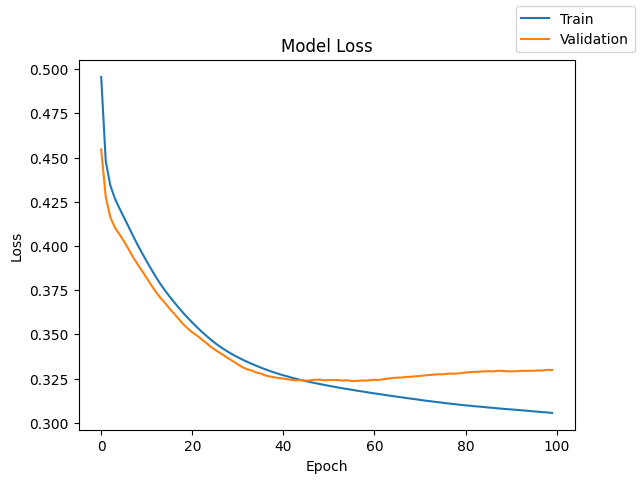

In [471]:
plot(history, 'loss')

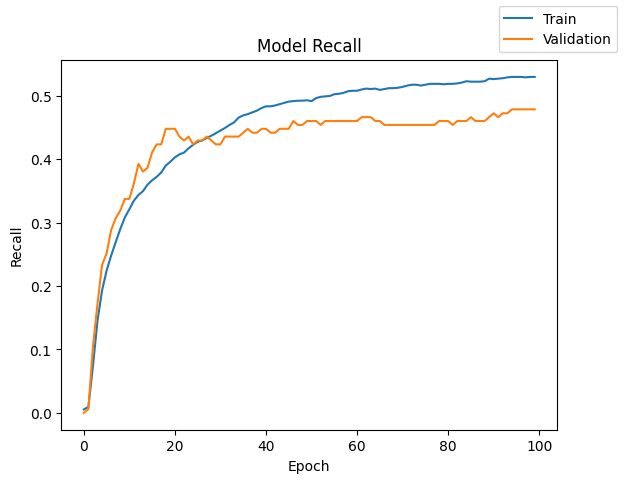

In [472]:
plot(history, 'recall')

25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step  


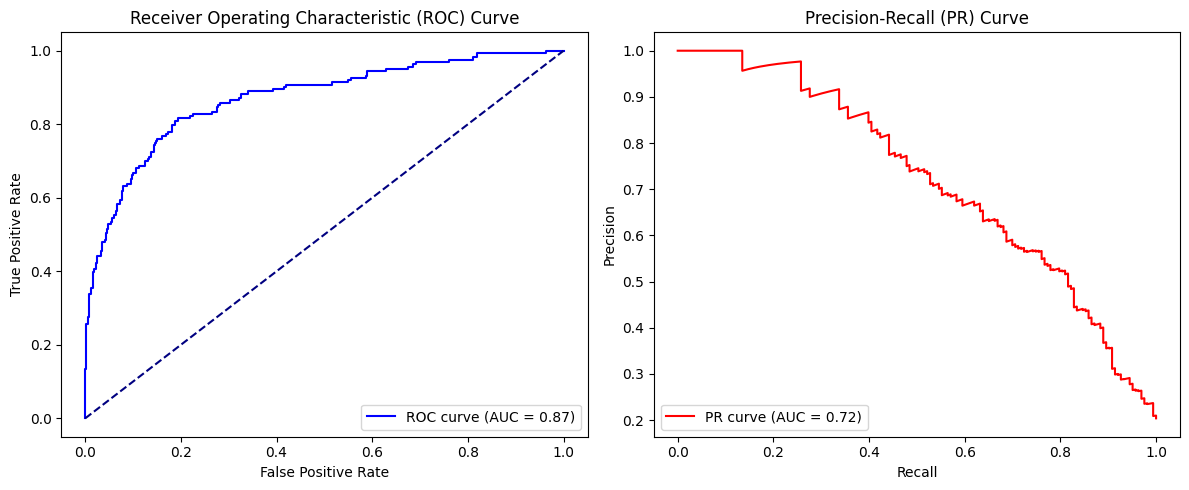

Best Threshold (from PR Curve & F1-score): 0.2948


0.2948046

In [473]:
Find_Best_Threshold(y_val,model_9.predict(X_val))

25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


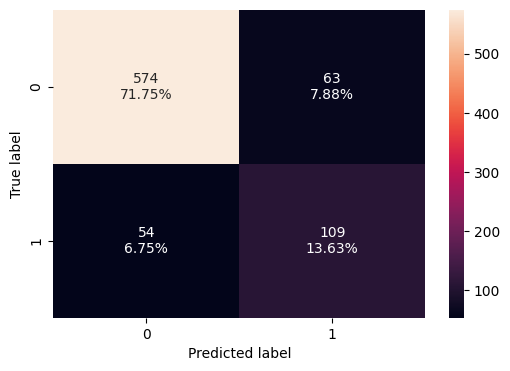

In [474]:
make_confusion_matrix(y_val,model_9.predict(X_val)>0.2948)

In [475]:
y_train_pred = model_9.predict(X_train)
y_train_pred = (y_train_pred > 0.2948)

y_val_pred = model_9.predict(X_val)
y_val_pred = (y_val_pred > 0.2948)

model_name = "Model 9 NN with ADAM | Two hidden layer | batch_size = 32, Epochs = 100"

train_metric_df.loc[model_name] = recall_score(y_train, y_train_pred)
valid_metric_df.loc[model_name] = recall_score(y_val, y_val_pred)

cr = classification_report(y_train, y_train_pred)
print(cr)

225/225 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
              precision    recall  f1-score   support

         0.0       0.92      0.89      0.91      5733
         1.0       0.63      0.71      0.67      1467

    accuracy                           0.86      7200
   macro avg       0.78      0.80      0.79      7200
weighted avg       0.86      0.86      0.86      7200



In [ ]:
#clearing session
clear_session() 

In [477]:
num_features = X_train.shape[1]
model_10 = Sequential([
    Dense(64, activation='relu', input_shape=(num_features,)),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
])
model_10.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 64)                  │             768 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,881 (11.25 KB)

 Trainable params: 2,881 (11.25 KB)

 Non-trainable params: 0 (0.00 B)

In [478]:
optimizer = keras.optimizers.Adam(learning_rate=0.0005)
model_10.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=[keras.metrics.Recall()])

In [479]:
batch_size = 32
epochs = 100
start_time = time.time()
history = model_10.fit(X_train, y_train, batch_size=batch_size, epochs=epochs, validation_data=(X_val, y_val))
end_time = time.time()

Epoch 1/100
225/225 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.5102 - recall: 0.0200 - val_loss: 0.4188 - val_recall: 0.1411
Epoch 2/100
225/225 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.4216 - recall: 0.1664 - val_loss: 0.4059 - val_recall: 0.2638
Epoch 3/100
225/225 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.4082 - recall: 0.2365 - val_loss: 0.4010 - val_recall: 0.2945
Epoch 4/100
225/225 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.4009 - recall: 0.2654 - val_loss: 0.3966 - val_recall: 0.2945
Epoch 5/100
225/225 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.3953 - recall: 0.2828 - val_loss: 0.3932 - val_recall: 0.2883
Epoch 6/100
225/225 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.3904 - recall: 0.3052 - val_loss: 0.3897 - val_recall: 0.3067
Epoch 7/100
225/225 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.3856 - recall: 0.3250 - val_loss: 0.3857 - val_recall: 0.3252
Epoch 8/100
225/225 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.3808 - recall: 0.3461 - val_loss: 0.3809 - val_recall: 0.3374


In [480]:
print(f'Time taken to train the model: {end_time-start_time} seconds')

Time taken to train the model: 58.43572473526001 seconds


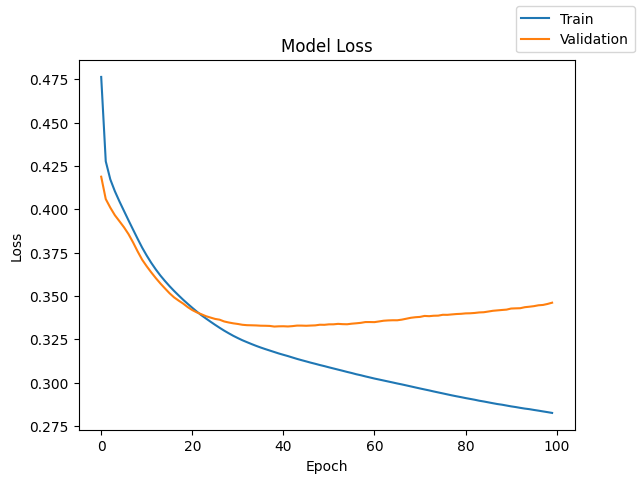

In [481]:
plot(history, 'loss')

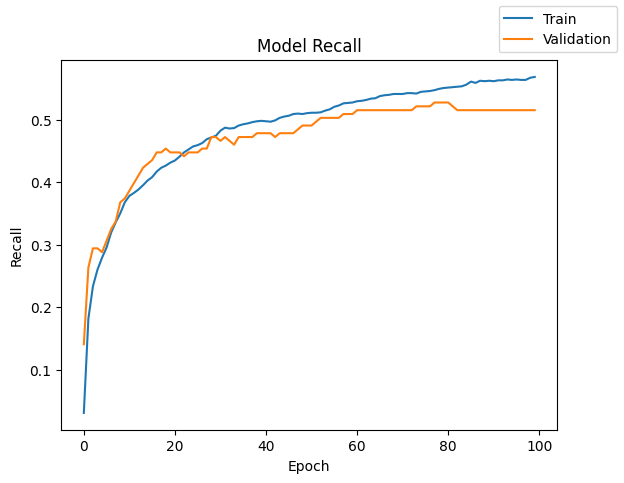

In [482]:
plot(history, 'recall')

25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step  


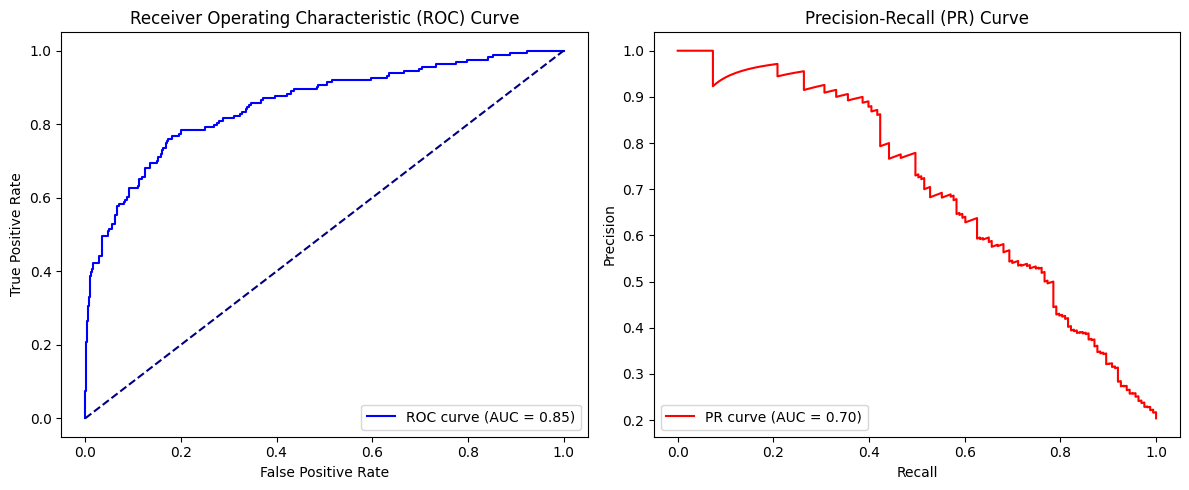

Best Threshold (from PR Curve & F1-score): 0.3877


0.3876903

In [483]:
Find_Best_Threshold(y_val,model_10.predict(X_val))

25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


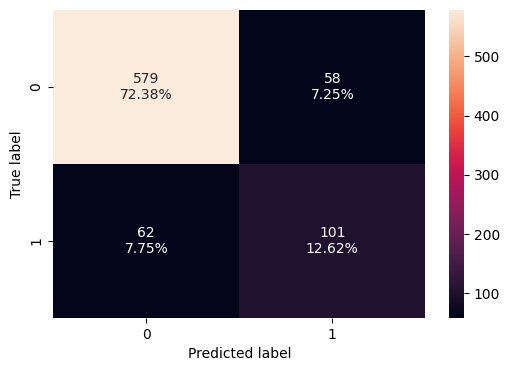

In [484]:
make_confusion_matrix(y_val,model_10.predict(X_val)>0.3877)

In [485]:
y_train_pred = model_10.predict(X_train)
y_train_pred = (y_train_pred > 0.3877)

y_val_pred = model_10.predict(X_val)
y_val_pred = (y_val_pred > 0.3877)

model_name = "Model 10 NN with ADAM | two hidden layer | batch_size = 32, Epochs = 100"

train_metric_df.loc[model_name] = recall_score(y_train, y_train_pred)
valid_metric_df.loc[model_name] = recall_score(y_val, y_val_pred)

cr = classification_report(y_train, y_train_pred)
print(cr)

225/225 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
              precision    recall  f1-score   support

         0.0       0.93      0.91      0.92      5733
         1.0       0.67      0.72      0.69      1467

    accuracy                           0.87      7200
   macro avg       0.80      0.81      0.81      7200
weighted avg       0.87      0.87      0.87      7200



# Neural Network wit Adam Optiizer and Dropout

In [486]:
#clearing session
clear_session()

In [487]:
num_features = X_train.shape[1]
model_11 = Sequential([
    Dense(64, activation='relu', input_shape=(num_features,)),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dropout(0.1),
    Dense(1, activation='sigmoid')
])
model_11.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 64)                  │             768 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,881 (11.25 KB)

 Trainable params: 2,881 (11.25 KB)

 Non-trainable params: 0 (0.00 B)

In [488]:
optimizer = keras.optimizers.Adam(learning_rate=0.0005)
model_11.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=[keras.metrics.Recall()])

In [489]:
batch_size = 32
epochs = 100
start_time = time.time()
history = model_11.fit(X_train, y_train, batch_size=batch_size, epochs=epochs, validation_data=(X_val, y_val))
end_time = time.time()

Epoch 1/100
225/225 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.5606 - recall: 0.1387 - val_loss: 0.4266 - val_recall: 0.0491
Epoch 2/100
225/225 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.4403 - recall: 0.0890 - val_loss: 0.4109 - val_recall: 0.1902
Epoch 3/100
225/225 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.4329 - recall: 0.1558 - val_loss: 0.4061 - val_recall: 0.2331
Epoch 4/100
225/225 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.4227 - recall: 0.1929 - val_loss: 0.4026 - val_recall: 0.2699
Epoch 5/100
225/225 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.4111 - recall: 0.2350 - val_loss: 0.3991 - val_recall: 0.2883
Epoch 6/100
225/225 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.4133 - recall: 0.2675 - val_loss: 0.3954 - val_recall: 0.3190
Epoch 7/100
225/225 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.4048 - recall: 0.2731 - val_loss: 0.3920 - val_recall: 0.3374
Epoch 8/100
225/225 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.4019 - recall: 0.2939 - val_loss: 0.3882 - val_recall: 0.3313


In [490]:
print(f'Time taken to train the model: {end_time-start_time} seconds')

Time taken to train the model: 60.710750579833984 seconds


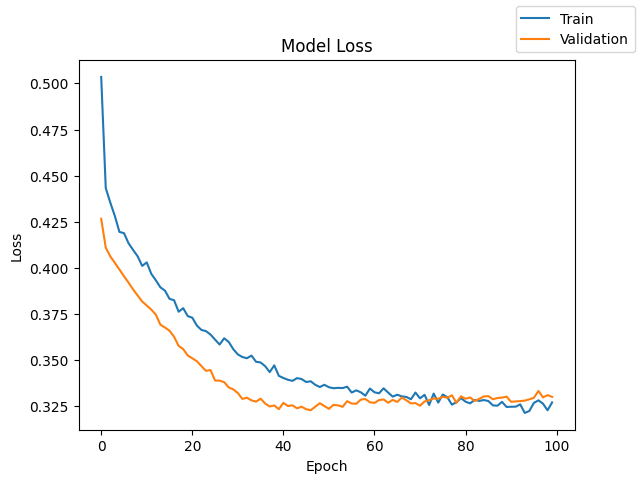

In [491]:
plot(history, 'loss')

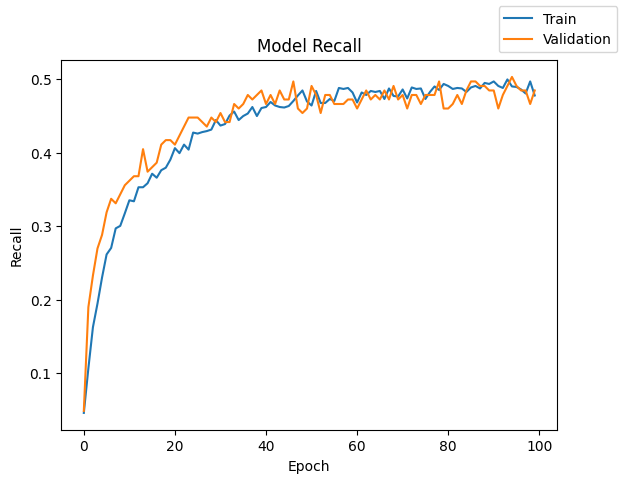

In [492]:
plot(history, 'recall')

25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step  


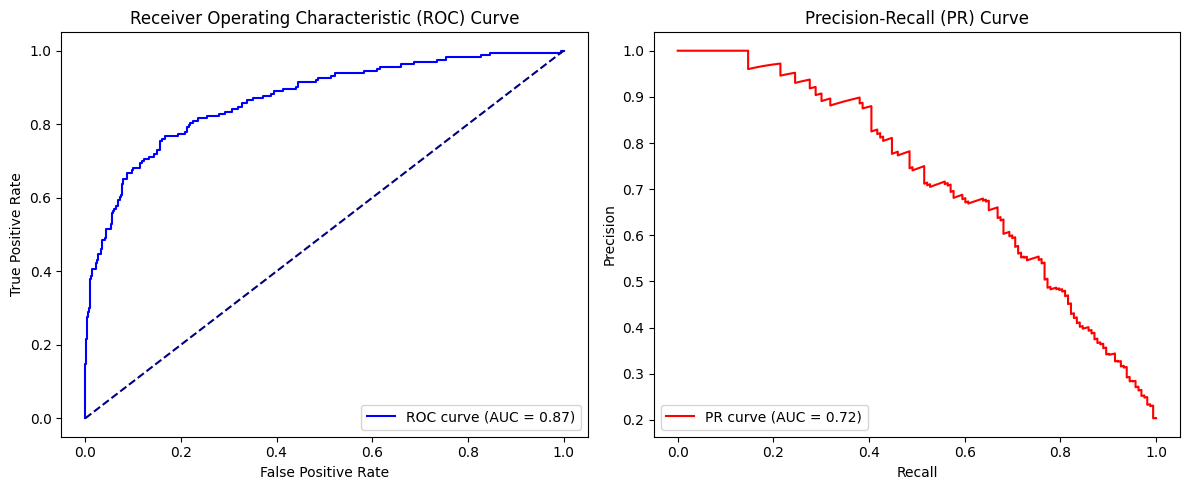

Best Threshold (from PR Curve & F1-score): 0.3130


0.3129622

In [493]:
Find_Best_Threshold(y_val,model_11.predict(X_val))

25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


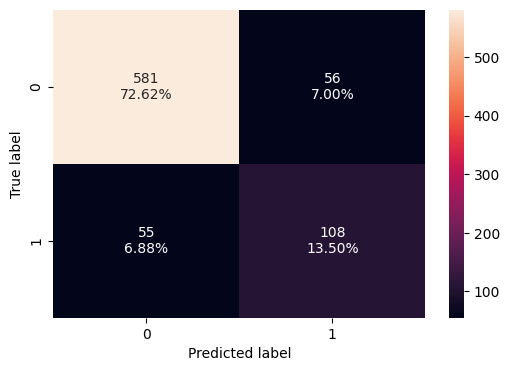

In [494]:
make_confusion_matrix(y_val,model_11.predict(X_val)>0.3130)

In [495]:
y_train_pred = model_11.predict(X_train)
y_train_pred = (y_train_pred > 0.3130)

y_val_pred = model_11.predict(X_val)
y_val_pred = (y_val_pred > 0.3130)

model_name = "Model 11 NN with ADAM | two hidden layer | Two Dropouts | batch_size = 32, Epochs = 100"

train_metric_df.loc[model_name] = recall_score(y_train, y_train_pred)
valid_metric_df.loc[model_name] = recall_score(y_val, y_val_pred)

cr = classification_report(y_train, y_train_pred)
print(cr)

225/225 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
              precision    recall  f1-score   support

         0.0       0.92      0.90      0.91      5733
         1.0       0.63      0.69      0.66      1467

    accuracy                           0.86      7200
   macro avg       0.78      0.79      0.78      7200
weighted avg       0.86      0.86      0.86      7200



In [496]:
# clearing session
clear_session()

In [497]:
num_features = X_train.shape[1]
model_12 = Sequential([
    Dense(32,activation='relu',input_shape=(num_features,)),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dense(32, activation='relu'),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid')
])
model_12.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 32)                  │             384 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 64)                  │           2,112 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 16)                  │             528 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 1)                   │              17 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 5,121 (20.00 KB)

 Trainable params: 5,121 (20.00 KB)

 Non-trainable params: 0 (0.00 B)

In [498]:
optimizer = keras.optimizers.Adam(learning_rate=0.0005)
model_12.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=[keras.metrics.Recall()])

In [499]:
batch_size = 32
epochs = 100
start_time = time.time()
history = model_12.fit(X_train, y_train, batch_size=batch_size, epochs=epochs, validation_data=(X_val, y_val))
end_time = time.time()

Epoch 1/100
225/225 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - loss: 0.5668 - recall: 0.1251 - val_loss: 0.4447 - val_recall: 0.0000e+00
Epoch 2/100
225/225 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.4641 - recall: 0.0170 - val_loss: 0.4221 - val_recall: 0.0061
Epoch 3/100
225/225 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.4403 - recall: 0.0513 - val_loss: 0.4160 - val_recall: 0.0552
Epoch 4/100
225/225 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.4364 - recall: 0.1014 - val_loss: 0.4131 - val_recall: 0.1227
Epoch 5/100
225/225 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.4311 - recall: 0.1254 - val_loss: 0.4078 - val_recall: 0.1656
Epoch 6/100
225/225 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.4285 - recall: 0.1483 - val_loss: 0.4075 - val_recall: 0.1902
Epoch 7/100
225/225 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.4297 - recall: 0.1648 - val_loss: 0.4049 - val_recall: 0.2393
Epoch 8/100
225/225 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.4226 - recall: 0.1938 - val_loss: 0.3971 - val_recall: 0.2

In [500]:
print(f'Time taken to train the model: {end_time-start_time} seconds')

Time taken to train the model: 63.83694243431091 seconds


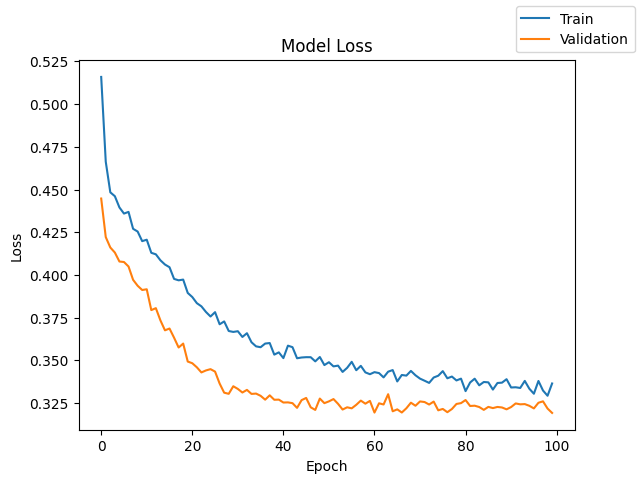

In [501]:
plot(history, 'loss')

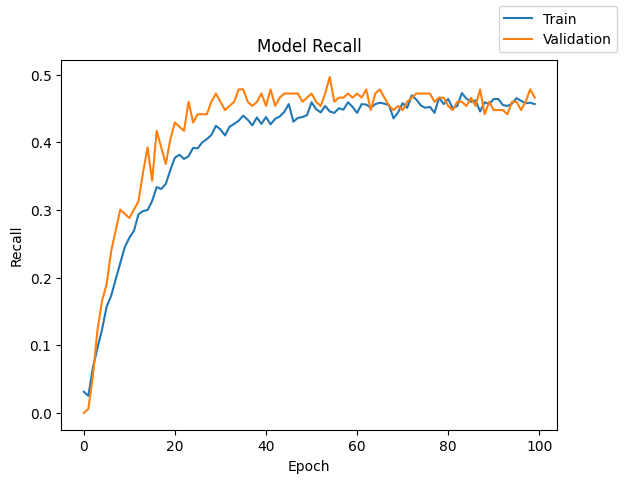

In [502]:
plot(history, 'recall')

25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step  


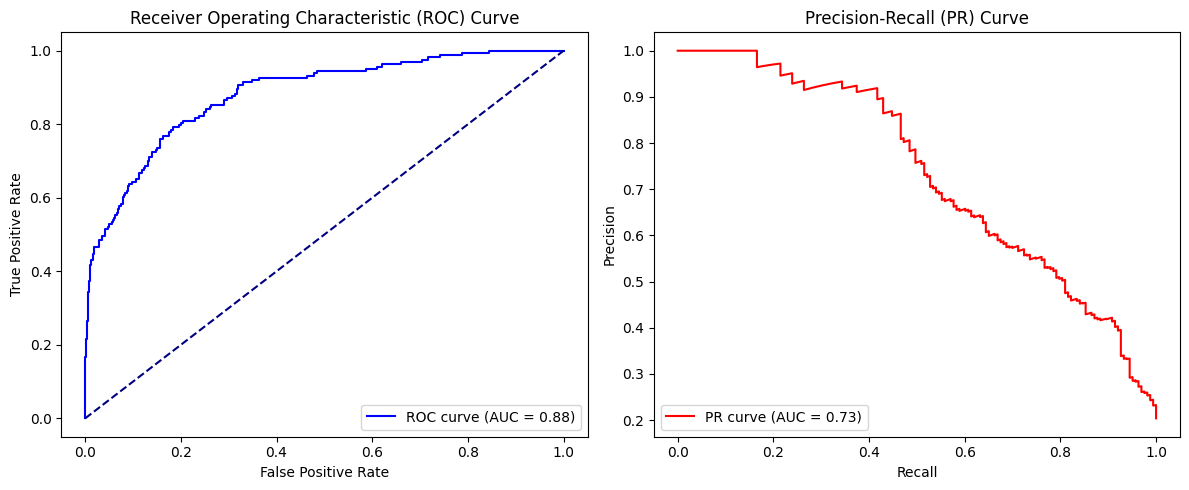

Best Threshold (from PR Curve & F1-score): 0.2236


0.22355467

In [503]:
Find_Best_Threshold(y_val,model_12.predict(X_val))

25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


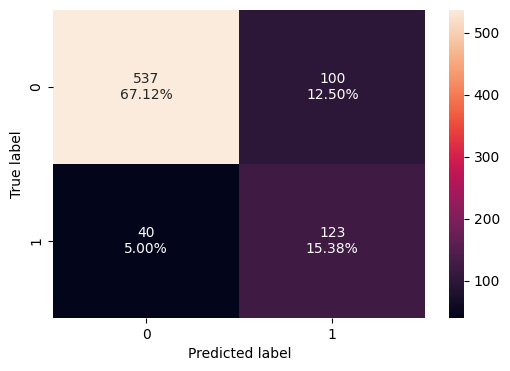

In [504]:
make_confusion_matrix(y_val,model_12.predict(X_val)>0.2236)

In [505]:
y_train_pred = model_12.predict(X_train)
y_train_pred = (y_train_pred > 0.2236)

y_val_pred = model_12.predict(X_val)
y_val_pred = (y_val_pred > 0.2236)

model_name = "Model 12 NN with ADAM | Four hidden layer | Two Dropouts | batch_size = 32, Epochs = 100"

train_metric_df.loc[model_name] = recall_score(y_train, y_train_pred)
valid_metric_df.loc[model_name] = recall_score(y_val, y_val_pred)

cr = classification_report(y_train, y_train_pred)
print(cr)

225/225 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
              precision    recall  f1-score   support

         0.0       0.93      0.81      0.87      5733
         1.0       0.51      0.78      0.62      1467

    accuracy                           0.80      7200
   macro avg       0.72      0.79      0.74      7200
weighted avg       0.85      0.80      0.82      7200



# Neural Network with Balanced Data (by applying SMOTE) and SGD Optimizer

In [506]:
# clearin session
clear_session()

In [507]:
# Initialize SMOTE
sm = SMOTE(random_state=42)

# Complete the code to fit SMOTE on the training data.
X_train_smote, y_train_smote = sm.fit_resample(X_train, y_train)

# Print the new shapes after SMOTE upsampling
print('After UpSampling, the shape of train_X: {}'.format(X_train_smote.shape))
print('After UpSampling, the shape of train_y: {} \n'.format(y_train_smote.shape))

After UpSampling, the shape of train_X: (11466, 11)
After UpSampling, the shape of train_y: (11466,) 



In [508]:
# picking the best model from sgd which is model_6 tuned
num_features = X_train_smote.shape[1]
model_13 = Sequential([
    Dense(32, activation='relu', input_shape=(num_features,)),
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid')
])
model_13.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 32)                  │             384 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 16)                  │             528 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 1)                   │              17 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 929 (3.63 KB)

 Trainable params: 929 (3.63 KB)

 Non-trainable params: 0 (0.00 B)

In [509]:
optimizer = keras.optimizers.SGD(learning_rate=0.01, momentum=0.9, nesterov=True)
model_13.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=[keras.metrics.Recall()])

In [510]:
batch_size = 32
epochs = 100
start_time = time.time()
history = model_13.fit(X_train_smote, y_train_smote, batch_size=batch_size, epochs=epochs, validation_data=(X_val, y_val))
end_time = time.time()

Epoch 1/100
359/359 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 0.6272 - recall: 0.5825 - val_loss: 0.4942 - val_recall: 0.6810
Epoch 2/100
359/359 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.5546 - recall: 0.7369 - val_loss: 0.4744 - val_recall: 0.6687
Epoch 3/100
359/359 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.5377 - recall: 0.7374 - val_loss: 0.4548 - val_recall: 0.6258
Epoch 4/100
359/359 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.5173 - recall: 0.7351 - val_loss: 0.4296 - val_recall: 0.6319
Epoch 5/100
359/359 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.4935 - recall: 0.7538 - val_loss: 0.4130 - val_recall: 0.6748
Epoch 6/100
359/359 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.4729 - recall: 0.7679 - val_loss: 0.3980 - val_recall: 0.6687
Epoch 7/100
359/359 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.4556 - recall: 0.7774 - val_loss: 0.3914 - val_recall: 0.6626
Epoch 8/100
359/359 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.4419 - recall: 0.7862 - val_loss: 0.3922 - val_recall: 0.6626


In [511]:
print(f'Time taken to train the model: {end_time-start_time} seconds')

Time taken to train the model: 84.44900155067444 seconds


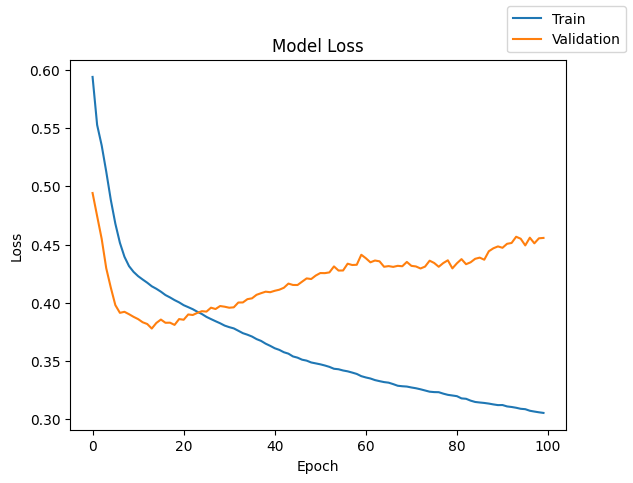

In [512]:
plot(history, 'loss')

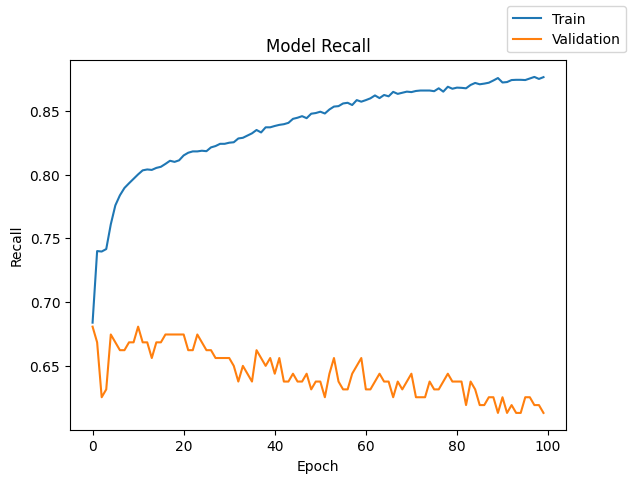

In [513]:
plot(history, 'recall')

25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step  


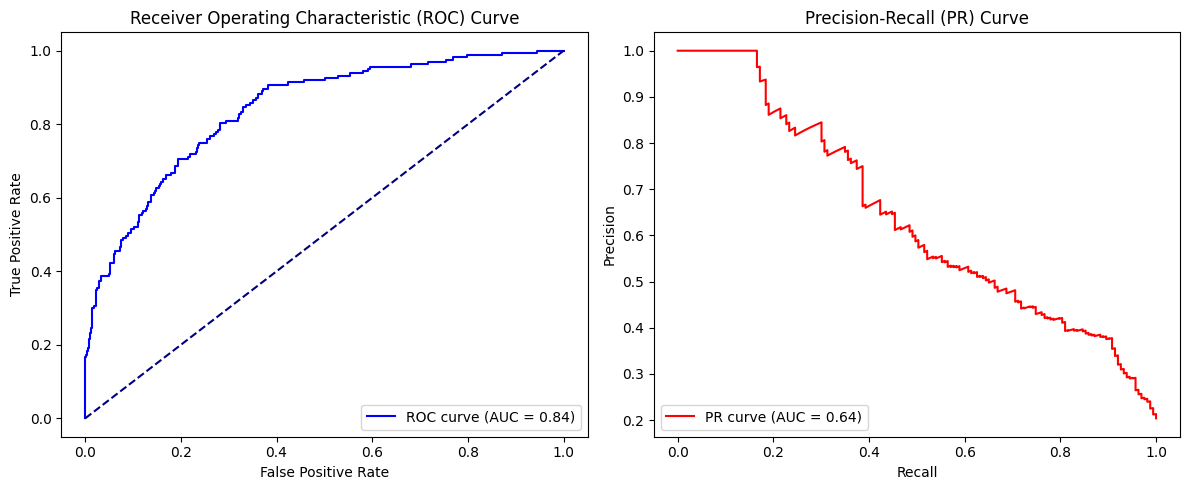

Best Threshold (from PR Curve & F1-score): 0.3687


0.3687162

In [514]:
Find_Best_Threshold(y_val,model_13.predict(X_val))

25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


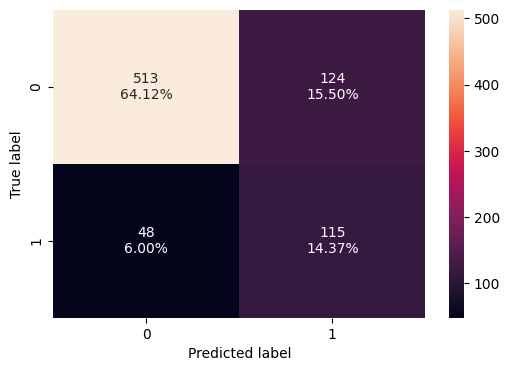

In [515]:
make_confusion_matrix(y_val,model_13.predict(X_val)>0.3687)

In [516]:
y_train_pred = model_13.predict(X_train_smote)
y_train_pred = (y_train_pred > 0.3687)

y_val_pred = model_13.predict(X_val)
y_val_pred = (y_val_pred > 0.3687)

model_name = "Model 13 NN with SGD | Two hidden layer | SMOTE | batch_size = 32, Epochs = 100"

train_metric_df.loc[model_name] = recall_score(y_train_smote, y_train_pred)
valid_metric_df.loc[model_name] = recall_score(y_val, y_val_pred)

cr = classification_report(y_train_smote, y_train_pred)
print(cr)

359/359 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
              precision    recall  f1-score   support

         0.0       0.90      0.84      0.87      5733
         1.0       0.85      0.91      0.88      5733

    accuracy                           0.87     11466
   macro avg       0.87      0.87      0.87     11466
weighted avg       0.87      0.87      0.87     11466



# Neural Network with Balanced Data (by applying SMOTE) and Adam Optimizer

In [517]:
#clearing session
clear_session()

In [518]:
#picking the best model with adam optimizer model_10 params for SMOTE
num_features = X_train_smote.shape[1]
model_14 = Sequential([
    Dense(64, activation='relu', input_shape=(num_features,)),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
])
model_14.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 64)                  │             768 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,881 (11.25 KB)

 Trainable params: 2,881 (11.25 KB)

 Non-trainable params: 0 (0.00 B)

In [519]:
# Define Adam optimizer with a custom learning rate
optimizer = keras.optimizers.Adam(learning_rate=0.0005)
model_14.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=[keras.metrics.Recall()])

In [520]:
batch_size = 32
epochs = 100
start_time = time.time()
history = model_14.fit(X_train_smote, y_train_smote, batch_size=batch_size, epochs=epochs, validation_data=(X_val, y_val))
end_time = time.time()

Epoch 1/100
359/359 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 0.6336 - recall: 0.5696 - val_loss: 0.5061 - val_recall: 0.6748
Epoch 2/100
359/359 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.5513 - recall: 0.7176 - val_loss: 0.4951 - val_recall: 0.6687
Epoch 3/100
359/359 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.5332 - recall: 0.7275 - val_loss: 0.4843 - val_recall: 0.6626
Epoch 4/100
359/359 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.5159 - recall: 0.7327 - val_loss: 0.4746 - val_recall: 0.6748
Epoch 5/100
359/359 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.4998 - recall: 0.7476 - val_loss: 0.4657 - val_recall: 0.7055
Epoch 6/100
359/359 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.4871 - recall: 0.7608 - val_loss: 0.4594 - val_recall: 0.7301
Epoch 7/100
359/359 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.4766 - recall: 0.7691 - val_loss: 0.4529 - val_recall: 0.7239
Epoch 8/100
359/359 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.4673 - recall: 0.7761 - val_loss: 0.4477 - val_recall: 0.7423


In [521]:
print(f'Time taken to train the model: {end_time-start_time} seconds')

Time taken to train the model: 86.29602289199829 seconds


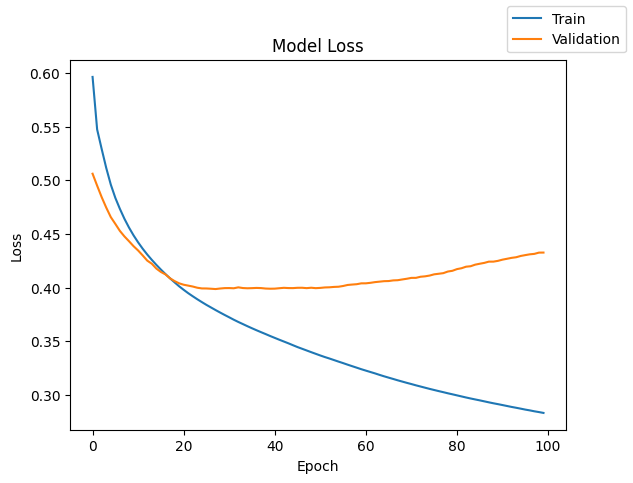

In [522]:
plot(history, 'loss')

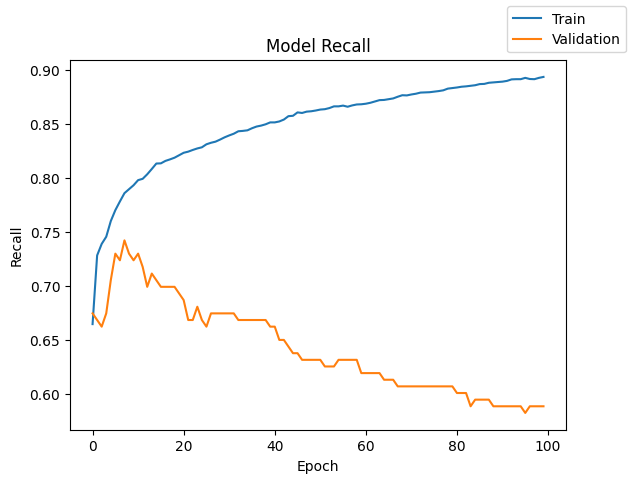

In [523]:
plot(history, 'recall')

25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step  


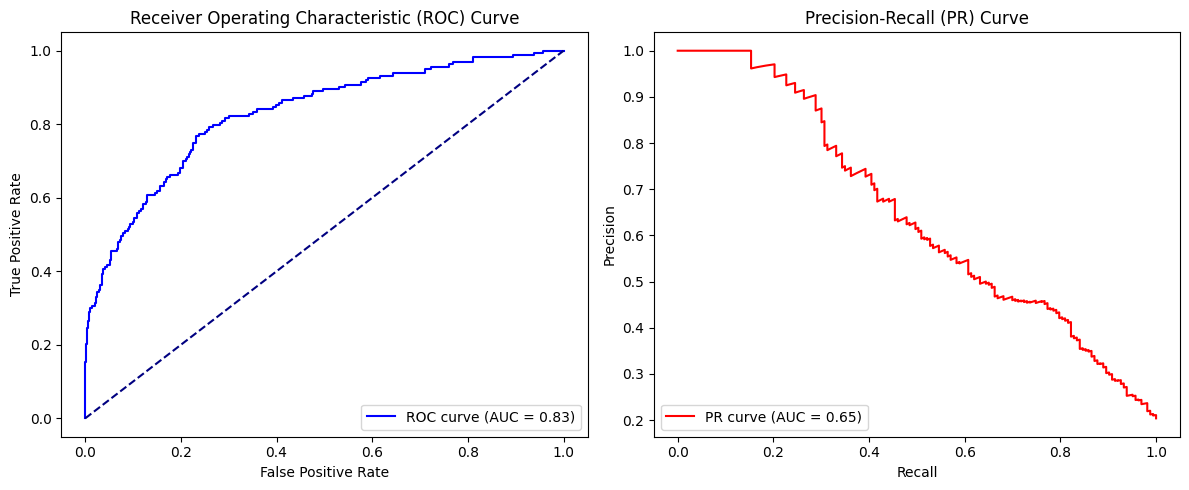

Best Threshold (from PR Curve & F1-score): 0.4766


0.4766351

In [524]:
Find_Best_Threshold(y_val,model_14.predict(X_val))

25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


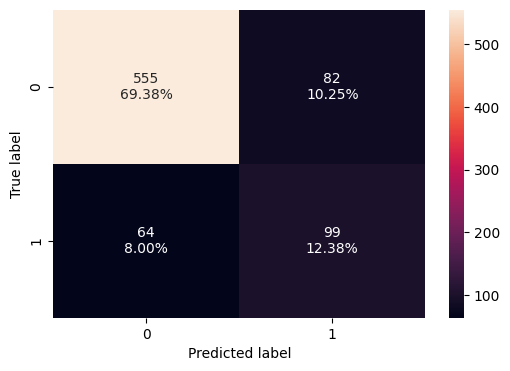

In [525]:
make_confusion_matrix(y_val,model_14.predict(X_val)>0.4766)

In [526]:
y_train_pred = model_14.predict(X_train_smote)
y_train_pred = (y_train_pred > 0.4766)

y_val_pred = model_14.predict(X_val)
y_val_pred = (y_val_pred > 0.4766)

model_name = "Model 14 NN with ADAM | Two hidden layer | SMOTE | batch_size = 32, Epochs = 100"

train_metric_df.loc[model_name] = recall_score(y_train_smote, y_train_pred)
valid_metric_df.loc[model_name] = recall_score(y_val, y_val_pred)

cr = classification_report(y_train_smote, y_train_pred)
print(cr)

359/359 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
              precision    recall  f1-score   support

         0.0       0.88      0.88      0.88      5733
         1.0       0.88      0.88      0.88      5733

    accuracy                           0.88     11466
   macro avg       0.88      0.88      0.88     11466
weighted avg       0.88      0.88      0.88     11466



# Neural Network with Balanced Data (by applying SMOTE), Adam Optimizer, and Dropout

In [527]:
#clearing session
clear_session()

In [528]:
num_features = X_train_smote.shape[1]
model_15 = Sequential([
    Dense(64, activation='relu', input_shape=(num_features,)),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dropout(0.1),
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid')
])
model_15.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 64)                  │             768 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 16)                  │             528 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 1)                   │              17 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 3,393 (13.25 KB)

 Trainable params: 3,393 (13.25 KB)

 Non-trainable params: 0 (0.00 B)

In [529]:
# Define Adam optimizer with a custom learning rate
optimizer = keras.optimizers.Adam(learning_rate=0.0005)
model_15.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=[keras.metrics.Recall()])

In [530]:
batch_size = 32
epochs = 100
start_time = time.time()
history = model_15.fit(X_train_smote, y_train_smote, batch_size=batch_size, epochs=epochs, validation_data=(X_val, y_val))
end_time = time.time()

Epoch 1/100
359/359 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - loss: 0.6502 - recall: 0.7387 - val_loss: 0.5082 - val_recall: 0.6748
Epoch 2/100
359/359 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.5722 - recall: 0.7089 - val_loss: 0.4965 - val_recall: 0.6687
Epoch 3/100
359/359 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.5524 - recall: 0.7092 - val_loss: 0.4889 - val_recall: 0.6871
Epoch 4/100
359/359 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.5369 - recall: 0.7200 - val_loss: 0.4741 - val_recall: 0.6994
Epoch 5/100
359/359 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.5211 - recall: 0.7289 - val_loss: 0.4604 - val_recall: 0.6994
Epoch 6/100
359/359 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.5112 - recall: 0.7332 - val_loss: 0.4572 - val_recall: 0.7055
Epoch 7/100
359/359 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.5027 - recall: 0.7469 - val_loss: 0.4479 - val_recall: 0.6933
Epoch 8/100
359/359 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.4950 - recall: 0.7411 - val_loss: 0.4486 - val_recall: 0.7239


In [531]:
print(f'Time taken to train the model: {end_time-start_time} seconds')

Time taken to train the model: 92.01953983306885 seconds


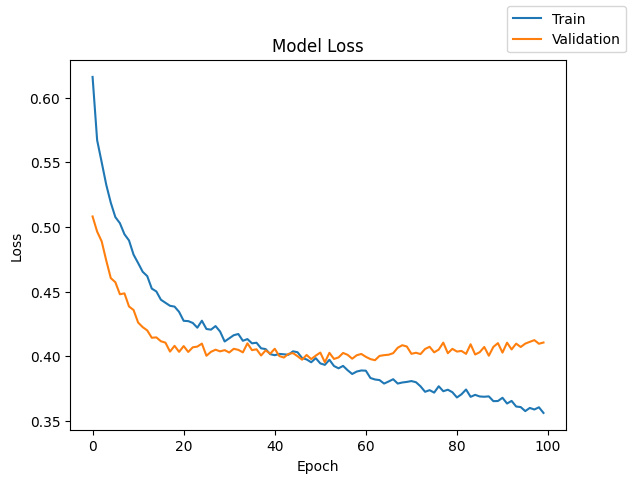

In [532]:
plot(history, 'loss')

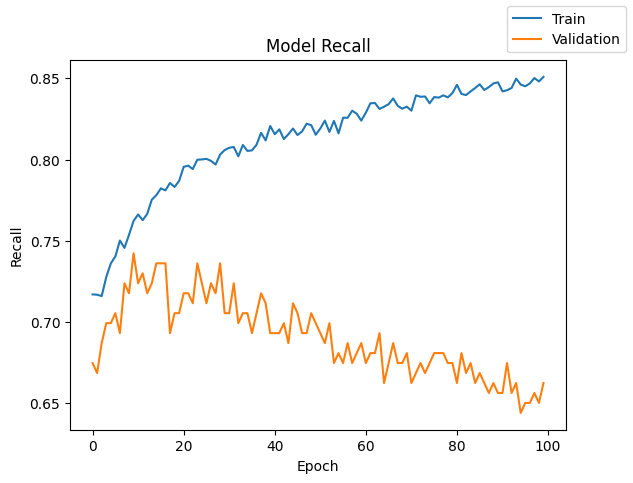

In [533]:
plot(history, 'recall')

25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step  


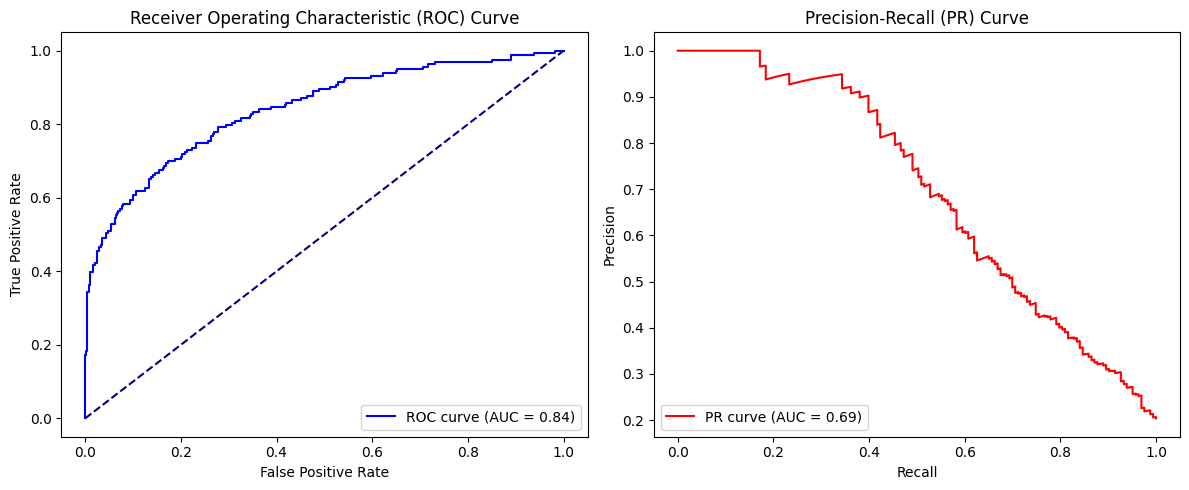

Best Threshold (from PR Curve & F1-score): 0.6493


0.64925927

In [534]:
Find_Best_Threshold(y_val,model_15.predict(X_val))

25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


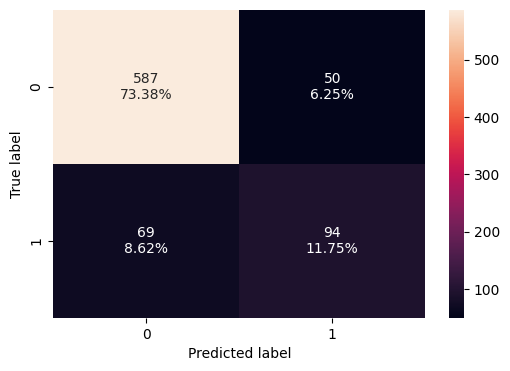

In [535]:
make_confusion_matrix(y_val,model_15.predict(X_val)>0.6493)

In [536]:
y_train_pred = model_15.predict(X_train_smote)
y_train_pred = (y_train_pred > 0.6493)

y_val_pred = model_15.predict(X_val)
y_val_pred = (y_val_pred > 0.6493)

model_name = "Model 15 NN with ADAM | three hidden layer | Two Dropouts | SMOTE | batch_size = 32, Epochs = 100"

train_metric_df.loc[model_name] = recall_score(y_train_smote, y_train_pred)
valid_metric_df.loc[model_name] = recall_score(y_val, y_val_pred)

cr = classification_report(y_train_smote, y_train_pred)
print(cr)

359/359 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
              precision    recall  f1-score   support

         0.0       0.81      0.92      0.86      5733
         1.0       0.91      0.78      0.84      5733

    accuracy                           0.85     11466
   macro avg       0.86      0.85      0.85     11466
weighted avg       0.86      0.85      0.85     11466



# Model Performance Comparison and Final Model Selection

In [537]:
print("Training performance comparison")
train_metric_df

Training performance comparison


,recall
"Model 0 NN with SGD | no hidden layers | batch_size = 32, Epochs = 10",0.622359
"Model 1 NN with SGD | no hidden layers | batch_size = 32, Epochs = 50",0.468984
"Model 2 NN with SGD | no hidden layers | batch_size = 64, Epochs = 50",0.644172
"Model 3 NN with SGD | no hidden layers | batch_size = 64, Epochs = 100",0.644172
"Model 4 NN with SGD | no hidden layers | batch_size = 32, Epochs = 100",0.468984
"Model 5 NN with SGD | one hidden layer | batch_size = 32, Epochs = 100",0.644853
"Model 6 NN with SGD | two hidden layer | batch_size = 32, Epochs = 100",0.708248
"Model 7 NN with SGD | three hidden layer | batch_size = 32, Epochs = 100",0.762100
"Model 8 NN with SGD | three hidden layer | batch_size = 64, Epochs = 100",0.730061
"Model 9 NN with ADAM | Two hidden layer | batch_size = 32, Epochs = 100",0.711656


In [538]:
print("Validation set performance comparison")
valid_metric_df

Validation set performance comparison


,recall
"Model 0 NN with SGD | no hidden layers | batch_size = 32, Epochs = 10",0.619632
"Model 1 NN with SGD | no hidden layers | batch_size = 32, Epochs = 50",0.496933
"Model 2 NN with SGD | no hidden layers | batch_size = 64, Epochs = 50",0.662577
"Model 3 NN with SGD | no hidden layers | batch_size = 64, Epochs = 100",0.656442
"Model 4 NN with SGD | no hidden layers | batch_size = 32, Epochs = 100",0.496933
"Model 5 NN with SGD | one hidden layer | batch_size = 32, Epochs = 100",0.656442
"Model 6 NN with SGD | two hidden layer | batch_size = 32, Epochs = 100",0.644172
"Model 7 NN with SGD | three hidden layer | batch_size = 32, Epochs = 100",0.711656
"Model 8 NN with SGD | three hidden layer | batch_size = 64, Epochs = 100",0.674847
"Model 9 NN with ADAM | Two hidden layer | batch_size = 32, Epochs = 100",0.668712


In [539]:
train_metric_df - valid_metric_df

,recall
"Model 0 NN with SGD | no hidden layers | batch_size = 32, Epochs = 10",0.002727
"Model 1 NN with SGD | no hidden layers | batch_size = 32, Epochs = 50",-0.027948
"Model 2 NN with SGD | no hidden layers | batch_size = 64, Epochs = 50",-0.018405
"Model 3 NN with SGD | no hidden layers | batch_size = 64, Epochs = 100",-0.012270
"Model 4 NN with SGD | no hidden layers | batch_size = 32, Epochs = 100",-0.027948
"Model 5 NN with SGD | one hidden layer | batch_size = 32, Epochs = 100",-0.011588
"Model 6 NN with SGD | two hidden layer | batch_size = 32, Epochs = 100",0.064076
"Model 7 NN with SGD | three hidden layer | batch_size = 32, Epochs = 100",0.050443
"Model 8 NN with SGD | three hidden layer | batch_size = 64, Epochs = 100",0.055215
"Model 9 NN with ADAM | Two hidden layer | batch_size = 32, Epochs = 100",0.042945


# *** Though Model 12 NN with ADAM | Four hidden layer | Two Dropouts | batch_size = 32, Epochs = 100 is the best with only train vs validation gap of 0.0218 and recall is over 75 on validation set, model 12 is scoring at 58 for recall on test set which is too low and the second best option is Model 9 NN with ADAM | Two hidden layer | batch_size = 32, Epochs = 100 with recall difference of 0.04 and high recall score with test set at 71.5 ***

In [540]:
# Check if test samples exist in training/validation sets
train_test_overlap = X_train.merge(X_test, how='inner')
print(f"Number of overlapping records in train and test set: {train_test_overlap.shape[0]}")

Number of overlapping records in train and test set: 0


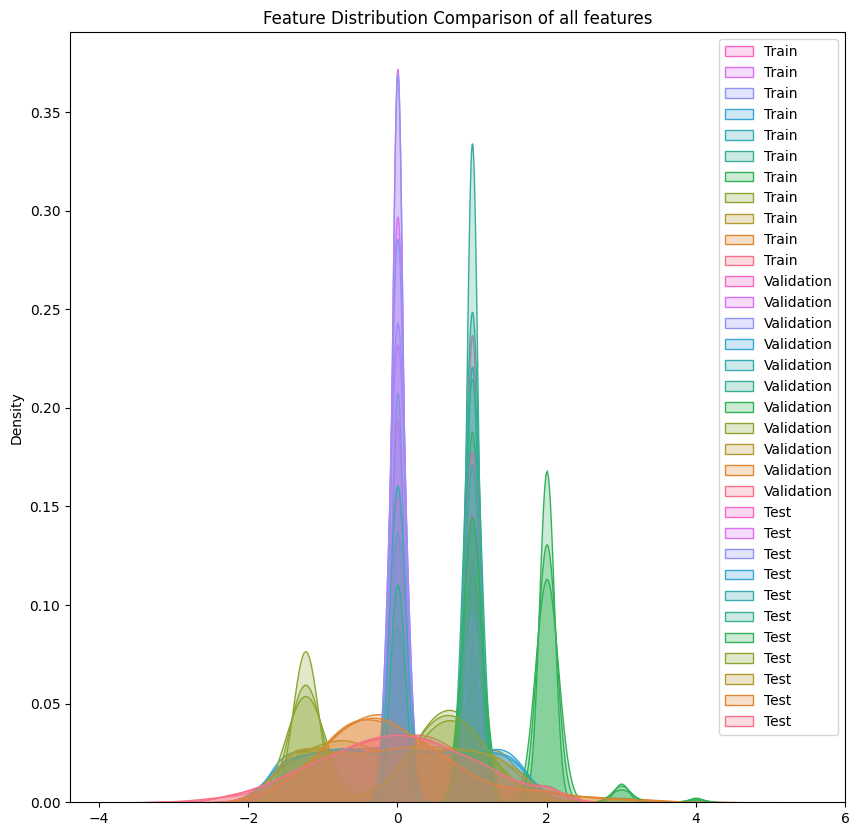

In [541]:
# Plotting all features to identify the distribution among traing, val and test sets
plt.figure(figsize=(10, 10))
sns.kdeplot(X_train, label='Train', fill=True)
sns.kdeplot(X_val, label='Validation', fill=True)
sns.kdeplot(X_test, label='Test', fill=True)
plt.legend()
plt.title("Feature Distribution Comparison of all features")
plt.show()

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


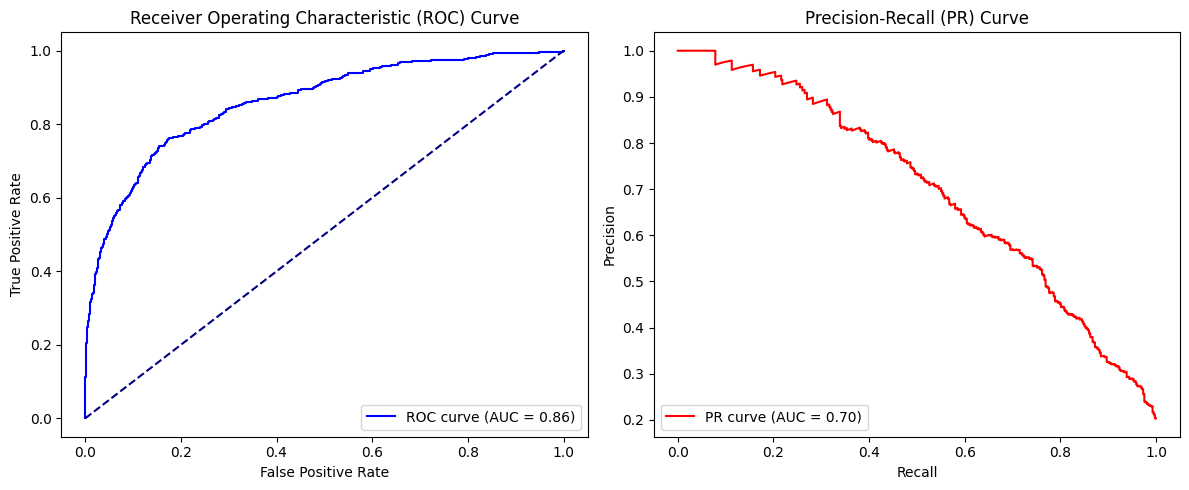

Best Threshold (from PR Curve & F1-score): 0.2583


0.25833756

In [542]:
Find_Best_Threshold(y_test,model_9.predict(X_test))

In [543]:
y_test_pred = model_9.predict(X_test)
y_test_pred = (y_test_pred > 0.2583)
print(y_test_pred)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
[[False]
 [False]
 [False]
 ...
 [ True]
 [False]
 [False]]


In [544]:
cr = classification_report(y_test, y_test_pred)
print(cr)

              precision    recall  f1-score   support

         0.0       0.92      0.86      0.89      1593
         1.0       0.57      0.71      0.63       407

    accuracy                           0.83      2000
   macro avg       0.75      0.79      0.76      2000
weighted avg       0.85      0.83      0.84      2000



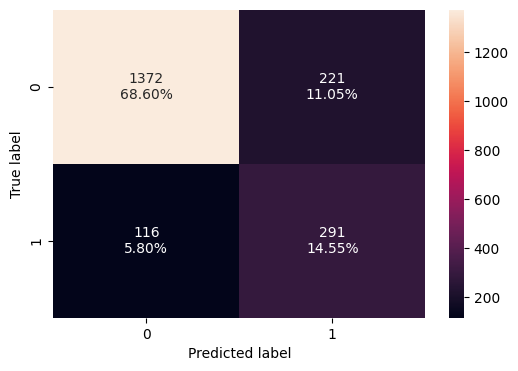

In [545]:
#confusion matrix for best model
make_confusion_matrix(y_test,y_test_pred)

In [546]:
best_model_test_score = recall_score(y_test, y_test_pred)
print(f'Recall for best model with test set: {best_model_test_score}')

Recall for best model with test set: 0.714987714987715


PermutationExplainer explainer: 501it [00:51,  7.78it/s]


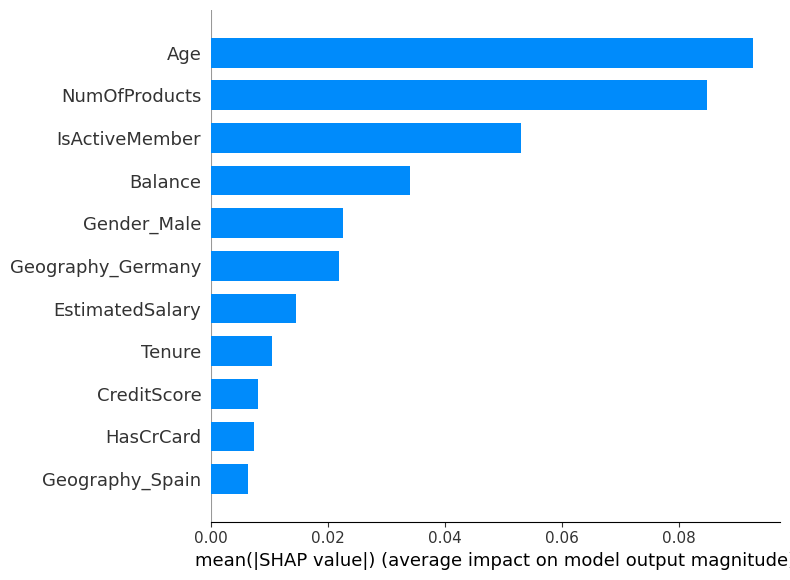

In [547]:
import shap

# Select a small subset of data to save compute
X_sample = X_test[:500]  # Using only 500 samples
explainer = shap.Explainer(model_9, X_sample)
shap_values = explainer(X_sample)

# Plot Feature Importance
shap.summary_plot(shap_values, X_sample, plot_type="bar")

# Actionable Insights and Business Recommendations

### Insights from the model



*   **Age is the Most Influential Feature,**
possible reason: Older customers might be switching to competitors with better retirement plans or reducing financial activity.
*   **Number of Products (NumOfProducts) Strongly Influences Churn,** possible reason: Single-product customers do not feel tied to the bank.
*   **Active Membership (IsActiveMember) is Critical,** possible reason: Customers who rarely engage with their bank might be considering switching.
*   **Balance Impacts Churn, but Not as Strongly as Expected,** possible reason: Customers with zero balance accounts may already be disengaged.
*   **Gender Matters: Males are More Likely to Churn than Females,** possible reason: Male customers might be more financially mobile and switch banks based on better offers.
*   **Geographic Influence: Germany Has Higher Churn Than Spain,** possible reason: The German market might have stronger banking competition, leading to higher customer exits.
*   **Credit Score & HasCrCard Have Low Impact,** possible reason: Customers may churn due to service dissatisfaction rather than credit issues.





### Business Recommendations



*   **Age**


1.   Offer personalized financial planning services for older customers.
2.   Introduce loyalty programs to retain them.


*   **Number of Products**


1.    Upsell & cross-sell additional banking products (loans, insurance, credit cards).
2.   Offer bundle discounts for customers with multiple products.


*   **Active Membership**


1.   Increase engagement through cashback offers, exclusive deals, and rewards programs.
2.   Encourage more transactions via push notifications & personalized banking insights.


*   **Balance Impacts**


1.    Offer better interest rates for high-balance customers to retain them.
2.  Educate low-balance customers on benefits of savings & investment plans.


*   **Gender**


1.   Understand key reasons behind male churn
2.   Introduce targeted banking solutions for male customers


*   **Geographic Influence**


1.   Conduct competitive analysis on German banking trends
2.   Offer Germany-specific banking benefits to reduce churn in that region.


*   **Credit Score**


1.   Focus more on customer engagement strategies rather than credit policies.




